<a href="https://colab.research.google.com/github/kawastony/Quantum_Gravity/blob/main/Tests1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# ── Constants ──────────────────────────────────────────
MPl   = 1.0          # Planck mass (natural units)
Lam4  = 1.316        # energy scale^4
f     = 0.5 * MPl    # axion decay constant
phi0  = 0.495 * np.pi * f   # initial field value
Om_m  = 0.31         # matter density
H0    = 67.4         # km/s/Mpc (not needed in N-time)

# ── Potential ──────────────────────────────────────────
def V(phi):
    return Lam4 * (1 - np.cos(phi / f))

def dV(phi):
    return Lam4 / f * np.sin(phi / f)

# ── Hubble in e-fold time ──────────────────────────────
def H2(a, rho_phi):
    rho_m = Om_m * a**(-3)
    rho_r = 0.0   # negligible at DE era
    return (8 * np.pi / 3) * (rho_m + rho_phi)

# ── Field equations in N = ln(a) ──────────────────────
def equations(N, y, n_quantum=0, beta0=None):
    phi, dphi = y          # φ and φ' = dφ/dN
    a = np.exp(N)

    rho_phi = 0.5 * dphi**2 + V(phi)
    H2_val  = H2(a, rho_phi)
    H_val   = np.sqrt(abs(H2_val))

    # dH/dN from Friedmann
    rho_m   = Om_m * a**(-3)
    dH2_dN  = -4 * np.pi * (dphi**2 + rho_m)
    Hdot_over_H2 = 0.5 * dH2_dN / H2_val

    # Centrifugal term (n=0: off, n=1: on)
    if n_quantum > 0 and beta0 is not None:
        centrifugal = (n_quantum**2) / (beta0**2 * a**6 * H2_val)
    else:
        centrifugal = 0.0

    # Klein-Gordon in N-time
    ddphi = -(3 + Hdot_over_H2) * dphi \
            - dV(phi) / H2_val \
            - centrifugal

    return [dphi, ddphi]

# ── Equation of state ──────────────────────────────────
def w_phi(phi, dphi):
    KE = 0.5 * dphi**2
    PE = V(phi)
    return (KE - PE) / (KE + PE)

# ── CPL fit: w(z) = w0 + wa * z/(1+z) ─────────────────
def cpl(z, w0, wa):
    return w0 + wa * z / (1 + z)

# ── Integration ────────────────────────────────────────
def run_tifa(n_quantum=0, beta0=None):

    N_i = -7.0          # start at z ~ 1096 (recombination)
    N_f =  0.0          # end at z = 0
    y0  = [phi0, 0.0]   # field frozen initially

    sol = solve_ivp(
        equations,
        [N_i, N_f],
        y0,
        args=(n_quantum, beta0),
        method='RK45',
        max_step=0.01,
        rtol=1e-9,
        atol=1e-12,
        dense_output=True
    )

    # Sample w(z) over z in [0, 2]
    z_arr   = np.linspace(0, 2, 200)
    N_arr   = np.log(1 / (1 + z_arr))
    w_arr   = []

    for Nval in N_arr:
        state   = sol.sol(Nval)
        phi_v   = state[0]
        dphi_v  = state[1]
        w_arr.append(w_phi(phi_v, dphi_v))

    w_arr = np.array(w_arr)

    # Fit CPL
    popt, _ = curve_fit(cpl, z_arr, w_arr, p0=[-0.9, -0.1])
    w0_fit, wa_fit = popt

    return w0_fit, wa_fit, z_arr, w_arr

# ── RUN 1: Classical (n=0, L_theta=0) ──────────────────
w0_cl, wa_cl, z_cl, w_cl = run_tifa(n_quantum=0)

print("=" * 45)
print("RUN 1: Classical TIFA (n=0, L_theta=0)")
print(f"  w0 (classical) = {w0_cl:.4f}")
print(f"  wa (classical) = {wa_cl:.4f}")
print("=" * 45)

# ── RUN 2: Quantum (n=1, centrifugal active) ────────────
beta0 = f    # cone radius ~ axion decay constant
w0_qu, wa_qu, z_qu, w_qu = run_tifa(n_quantum=1, beta0=beta0)

print("RUN 2: Quantum TIFA (n=1, L_theta=hbar)")
print(f"  w0 (quantum)   = {w0_qu:.4f}")
print(f"  wa (quantum)   = {wa_qu:.4f}")
print("=" * 45)

# ── RESULT ─────────────────────────────────────────────
delta_wa = wa_qu - wa_cl

print("RESULT:")
print(f"  wa (classical) = {wa_cl:.4f}")
print(f"  wa (quantum)   = {wa_qu:.4f}")
print(f"  delta_wa (n=1) = {delta_wa:.4f}")
print(f"  wa (observed)  = -0.137")
print(f"  Residual       = {-0.137 - wa_qu:.4f}")
print("=" * 45)

if abs(delta_wa) > 0.05:
    print("FINDING: Quantum angular mode")
    print("contributes significantly to wa.")
    print("TCSFT QG-DE connection is real.")
elif abs(delta_wa) < 0.01:
    print("FINDING: wa is purely classical.")
    print("Quantum correction negligible.")
    print("QG structure exists but does")
    print("not shift observable wa.")
else:
    print("FINDING: Mixed contribution.")
    print("Partial quantum origin of wa.")
    print("Publishable and interesting.")

RUN 1: Classical TIFA (n=0, L_theta=0)
  w0 (classical) = -0.9980
  wa (classical) = -0.0033
RUN 2: Quantum TIFA (n=1, L_theta=hbar)
  w0 (quantum)   = 0.9974
  wa (quantum)   = 0.0041
RESULT:
  wa (classical) = -0.0033
  wa (quantum)   = 0.0041
  delta_wa (n=1) = 0.0074
  wa (observed)  = -0.137
  Residual       = -0.1411
FINDING: wa is purely classical.
Quantum correction negligible.
QG structure exists but does
not shift observable wa.


In [2]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

MPl  = 1.0
Lam4 = 1.316
f    = 0.5 * MPl
Om_m = 0.31

def V(phi):
    return Lam4 * (1 - np.cos(phi / f))

def dV(phi):
    return Lam4 / f * np.sin(phi / f)

def equations(N, y):
    phi, dphi = y
    a = np.exp(N)
    rho_phi = 0.5 * dphi**2 + V(phi)
    rho_m   = Om_m * a**(-3)
    H2_val  = (8*np.pi/3) * (rho_m + rho_phi)
    dH2_dN  = -4*np.pi * (dphi**2 + rho_m)
    Hdot    = 0.5 * dH2_dN / H2_val
    ddphi   = -(3 + Hdot)*dphi - dV(phi)/H2_val
    return [dphi, ddphi]

def cpl(z, w0, wa):
    return w0 + wa * z/(1+z)

def run_classical(phi0_val):
    y0  = [phi0_val, 0.0]
    sol = solve_ivp(equations, [-7, 0], y0,
                    method='RK45', max_step=0.01,
                    rtol=1e-9, atol=1e-12,
                    dense_output=True)
    z_arr = np.linspace(0, 2, 200)
    N_arr = np.log(1/(1+z_arr))
    w_arr = []
    for Nv in N_arr:
        s = sol.sol(Nv)
        KE = 0.5*s[1]**2
        PE = V(s[0])
        w_arr.append((KE-PE)/(KE+PE))
    w_arr = np.array(w_arr)
    popt, _ = curve_fit(cpl, z_arr, w_arr, p0=[-0.9,-0.1])
    return popt[0], popt[1]

# Scan phi0 from 0.1 to 0.95 of pi*f
print(f"{'phi0/pi*f':>12} {'w0':>10} {'wa':>10}")
print("-" * 36)

target_wa = -0.137
best_phi0 = None
best_diff = 999

phi0_scan = np.linspace(0.1, 0.95, 35)

for p in phi0_scan:
    phi0_val = p * np.pi * f
    try:
        w0v, wav = run_classical(phi0_val)
        diff = abs(wav - target_wa)
        if diff < best_diff:
            best_diff = diff
            best_phi0 = p
        if abs(wav) > 0.01 or w0v > -0.7:
            print(f"{p:>12.3f} {w0v:>10.4f} {wav:>10.4f}  <-- active")
        else:
            print(f"{p:>12.3f} {w0v:>10.4f} {wav:>10.4f}")
    except:
        print(f"{p:>12.3f}  failed")

print("-" * 36)
print(f"Closest to wa=-0.137: phi0 = {best_phi0:.3f} pi*f")
print(f"Residual: {best_diff:.4f}")

   phi0/pi*f         w0         wa
------------------------------------
       0.100    -0.9750    -0.0445  <-- active
       0.125    -0.9775    -0.0398  <-- active
       0.150    -0.9801    -0.0351  <-- active
       0.175    -0.9827    -0.0304  <-- active
       0.200    -0.9851    -0.0261  <-- active
       0.225    -0.9872    -0.0223  <-- active
       0.250    -0.9891    -0.0188  <-- active
       0.275    -0.9908    -0.0159  <-- active
       0.300    -0.9922    -0.0133  <-- active
       0.325    -0.9935    -0.0112  <-- active
       0.350    -0.9945    -0.0093
       0.375    -0.9954    -0.0078
       0.400    -0.9961    -0.0065
       0.425    -0.9967    -0.0054
       0.450    -0.9973    -0.0045
       0.475    -0.9977    -0.0038
       0.500    -0.9981    -0.0032
       0.525    -0.9984    -0.0026
       0.550    -0.9986    -0.0022
       0.575    -0.9989    -0.0018
       0.600    -0.9991    -0.0015
       0.625    -0.9992    -0.0012
       0.650    -0.9994    -0.0010
   

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit, brentq

MPl  = 1.0
Om_m = 0.31

def V(phi, Lam4, f):
    return Lam4 * (1 - np.cos(phi / f))

def dV(phi, Lam4, f):
    return Lam4 / f * np.sin(phi / f)

def equations(N, y, Lam4, f):
    phi, dphi = y
    a = np.exp(N)
    rho_phi = 0.5*dphi**2 + V(phi, Lam4, f)
    rho_m   = Om_m * a**(-3)
    H2_val  = (8*np.pi/3)*(rho_m + rho_phi)
    dH2_dN  = -4*np.pi*(dphi**2 + rho_m)
    Hdot    = 0.5*dH2_dN/H2_val
    ddphi   = -(3+Hdot)*dphi - dV(phi,Lam4,f)/H2_val
    return [dphi, ddphi]

def cpl(z, w0, wa):
    return w0 + wa*z/(1+z)

def run_model(phi0_frac, Lam4, f):
    phi0 = phi0_frac * np.pi * f
    y0   = [phi0, 0.0]
    sol  = solve_ivp(equations, [-7,0], y0,
                     args=(Lam4, f),
                     method='RK45', max_step=0.01,
                     rtol=1e-9, atol=1e-12,
                     dense_output=True)
    z_arr = np.linspace(0, 2, 200)
    N_arr = np.log(1/(1+z_arr))
    w_arr = []
    for Nv in N_arr:
        s  = sol.sol(Nv)
        KE = 0.5*s[1]**2
        PE = V(s[0], Lam4, f)
        denom = KE + PE
        if abs(denom) < 1e-30:
            w_arr.append(-1.0)
        else:
            w_arr.append((KE-PE)/denom)
    w_arr = np.array(w_arr)
    try:
        popt,_ = curve_fit(cpl, z_arr, w_arr, p0=[-0.9,-0.1])
        return popt[0], popt[1]
    except:
        return None, None

# Ridge: Lam4 = 0.820 * f^0.316
# Scan f values on the ridge
# Scan phi0 fractions
# Find where wa = -0.137

print("Scanning ridge for wa = -0.137")
print(f"{'f/MPl':>8} {'Lam4':>8} {'phi0/pif':>10} "
      f"{'w0':>10} {'wa':>10}")
print("-"*52)

target_wa = -0.137
best = {'diff': 999, 'f': None, 'phi0': None,
        'w0': None, 'wa': None, 'Lam4': None}

f_values   = np.linspace(0.1, 0.9, 17)
phi0_fracs = np.linspace(0.05, 0.50, 20)

for f_val in f_values:
    Lam4 = 0.820 * f_val**0.316
    for p in phi0_fracs:
        w0v, wav = run_model(p, Lam4, f_val)
        if wav is None:
            continue
        diff = abs(wav - target_wa)
        if diff < best['diff']:
            best.update({'diff': diff,
                         'f': f_val,
                         'phi0': p,
                         'w0': w0v,
                         'wa': wav,
                         'Lam4': Lam4})
        if diff < 0.015:
            print(f"{f_val:>8.3f} {Lam4:>8.4f} "
                  f"{p:>10.3f} {w0v:>10.4f} {wav:>10.4f}  ***")

print("-"*52)
print(f"\nBest match to wa = -0.137:")
print(f"  f      = {best['f']:.3f} MPl")
print(f"  Lam4   = {best['Lam4']:.4f}")
print(f"  phi0   = {best['phi0']:.3f} pi*f")
print(f"  w0     = {best['w0']:.4f}")
print(f"  wa     = {best['wa']:.4f}")
print(f"  |diff| = {best['diff']:.4f}")

Scanning ridge for wa = -0.137
   f/MPl     Lam4   phi0/pif         w0         wa
----------------------------------------------------
   0.150   0.4503      0.287    -0.9194    -0.1436  ***
   0.150   0.4503      0.311    -0.9264    -0.1309  ***
   0.200   0.4931      0.050    -0.9238    -0.1364  ***
   0.200   0.4931      0.074    -0.9256    -0.1331  ***
   0.200   0.4931      0.097    -0.9280    -0.1287  ***
   0.200   0.4931      0.121    -0.9309    -0.1233  ***
----------------------------------------------------

Best match to wa = -0.137:
  f      = 0.200 MPl
  Lam4   = 0.4931
  phi0   = 0.050 pi*f
  w0     = -0.9238
  wa     = -0.1364
  |diff| = 0.0006


In [4]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

MPl  = 1.0
Om_m = 0.31

# Correct ridge parameters
f_best    = 0.200
Lam4_best = 0.4931
phi0_best = 0.050 * np.pi * f_best

def V(phi):
    return Lam4_best * (1 - np.cos(phi / f_best))

def dV(phi):
    return Lam4_best / f_best * np.sin(phi / f_best)

def equations(N, y, n_q=0, beta0=1.0):
    phi, dphi = y
    a       = np.exp(N)
    rho_phi = 0.5*dphi**2 + V(phi)
    rho_m   = Om_m * a**(-3)
    H2_val  = (8*np.pi/3)*(rho_m + rho_phi)
    dH2_dN  = -4*np.pi*(dphi**2 + rho_m)
    Hdot    = 0.5*dH2_dN/H2_val

    # Centrifugal term from cone geometry
    # Properly normalized:
    # rho_cent = n²ħ²/(2 beta0² a^6)
    # Force term = -d(rho_cent)/dphi
    #            = n²ħ²/(beta0² a^6 H²)
    # scaled by 1/H² for N-time equation
    if n_q > 0:
        cent = (n_q**2) / (beta0**2 * a**6 * H2_val)
    else:
        cent = 0.0

    ddphi = -(3 + Hdot)*dphi - dV(phi)/H2_val - cent
    return [dphi, ddphi]

def cpl(z, w0, wa):
    return w0 + wa*z/(1+z)

def run(n_q=0, beta0=1.0):
    y0  = [phi0_best, 0.0]
    sol = solve_ivp(equations, [-7,0], y0,
                    args=(n_q, beta0),
                    method='RK45', max_step=0.01,
                    rtol=1e-9, atol=1e-12,
                    dense_output=True)
    z_arr = np.linspace(0, 2, 200)
    N_arr = np.log(1/(1+z_arr))
    w_arr = []
    for Nv in N_arr:
        s  = sol.sol(Nv)
        KE = 0.5*s[1]**2
        PE = V(s[0])
        denom = KE + PE
        w_arr.append((KE-PE)/denom if abs(denom)>1e-30 else -1.0)
    w_arr = np.array(w_arr)
    popt,_ = curve_fit(cpl, z_arr, w_arr, p0=[-0.9,-0.1])
    return popt[0], popt[1]

# ── Classical baseline ─────────────────────────────────
w0_cl, wa_cl = run(n_q=0)
print("="*48)
print("CLASSICAL (n=0)")
print(f"  w0 = {w0_cl:.4f}")
print(f"  wa = {wa_cl:.4f}")

# ── Quantum n=1, scan beta0 ────────────────────────────
# beta0 is the cone equilibrium radius at cosmo scale
# Physical candidates:
#   beta0 = f          (axion scale)
#   beta0 = phi0       (initial field value)
#   beta0 = sqrt(f*MPl) (geometric mean)
#   beta0 = MPl        (Planck scale)

print("="*48)
print("QUANTUM (n=1), scanning beta0")
print(f"{'beta0/MPl':>12} {'w0':>10} {'wa':>10} {'delta_wa':>12}")
print("-"*48)

beta0_candidates = [
    ("phi0",          phi0_best),
    ("f",             f_best),
    ("sqrt(f*MPl)",   np.sqrt(f_best * MPl)),
    ("MPl",           MPl),
    ("f²/phi0",       f_best**2 / phi0_best),
]

for name, b0 in beta0_candidates:
    try:
        w0_q, wa_q = run(n_q=1, beta0=b0)
        dwa = wa_q - wa_cl
        print(f"{name:>12} {w0_q:>10.4f} {wa_q:>10.4f} {dwa:>12.4f}")
    except Exception as e:
        print(f"{name:>12}  failed: {e}")

print("="*48)
print(f"Target wa = -0.137")
print(f"Classical wa = {wa_cl:.4f}")
print(f"Needed delta_wa = {-0.137 - wa_cl:.4f}")

CLASSICAL (n=0)
  w0 = -0.9238
  wa = -0.1364
QUANTUM (n=1), scanning beta0
   beta0/MPl         w0         wa     delta_wa
------------------------------------------------
        phi0     1.0000     0.0000       0.1364
           f     0.9997     0.0004       0.1368
 sqrt(f*MPl)     0.9992     0.0013       0.1377
         MPl     0.9976     0.0037       0.1401
     f²/phi0     0.9967     0.0053       0.1417
Target wa = -0.137
Classical wa = -0.1364
Needed delta_wa = -0.0006


In [5]:
import numpy as np
from scipy.integrate import quad
from scipy.special import gamma

# Parameters at correct ridge point
f_val    = 0.200   # MPl
Lam4     = 0.4931
MPl      = 1.0
hbar     = 1.0     # natural units

# Effective mass of cosine potential
# V(phi) = Lam4*(1-cos(phi/f))
# Near phi=0: V ≈ Lam4*phi²/(2f²)
# So mu² = Lam4/f²
mu2  = Lam4 / f_val**2
mu   = np.sqrt(mu2)

print("="*48)
print("QUANTUM CONE GROUND STATE")
print(f"  f    = {f_val:.3f} MPl")
print(f"  Λ⁴   = {Lam4:.4f}")
print(f"  μ²   = Lam4/f² = {mu2:.4f}")
print(f"  μ    = {mu:.4f}")
print("="*48)

# Ground state wavefunction n=1 (angular):
# psi(beta) = beta * exp(-mu*beta²/(2*hbar))
# |psi|² = beta² * exp(-mu*beta²/hbar)

def norm_integrand(b):
    return b**2 * np.exp(-mu * b**2 / hbar)

def beta_integrand(b):
    return b**3 * np.exp(-mu * b**2 / hbar)

def beta2_integrand(b):
    return b**4 * np.exp(-mu * b**2 / hbar)

# Integrate numerically
norm_val,  _ = quad(norm_integrand,  0, np.inf)
beta_val,  _ = quad(beta_integrand,  0, np.inf)
beta2_val, _ = quad(beta2_integrand, 0, np.inf)

beta_mean  = beta_val  / norm_val
beta2_mean = beta2_val / norm_val
beta_rms   = np.sqrt(beta2_mean)
beta_std   = np.sqrt(beta2_mean - beta_mean**2)

print(f"\nGround state expectation values:")
print(f"  <β>     = {beta_mean:.6f} MPl")
print(f"  <β²>^½  = {beta_rms:.6f} MPl")
print(f"  σ_β     = {beta_std:.6f} MPl")

# Analytical cross-check
# For |psi|² ~ b² exp(-mu b²/hbar):
# <b> = Gamma(2)/(2*(mu/hbar)) /
#       [Gamma(3/2)/(2*(mu/hbar)^(3/2))]
# Using Gaussian integrals:
# ∫b^(2k+1) exp(-a b²) db = k!/(2 a^(k+1))
# ∫b^(2k) exp(-a b²) db = (2k-1)!!/(2^(k+1)) * sqrt(pi/a^(2k+1))

a = mu / hbar
# norm = ∫b² exp(-ab²)db = sqrt(pi)/(4 a^(3/2))
norm_analytic = np.sqrt(np.pi) / (4 * a**(3/2))
# <b> num = ∫b³ exp(-ab²)db = 1/(2a²)
beta_num_analytic = 1.0 / (2 * a**2)
beta_mean_analytic = beta_num_analytic / norm_analytic

print(f"\nAnalytical cross-check:")
print(f"  <β> analytical = {beta_mean_analytic:.6f} MPl")
print(f"  Agreement: {abs(beta_mean-beta_mean_analytic)<1e-6}")

# ── Now compare to phi0 ────────────────────────────────
phi0_target = 0.050 * np.pi * f_val
print(f"\nTarget φ₀ = 0.050 × π × f")
print(f"  φ₀ (numerical fit) = {phi0_target:.6f} MPl")
print(f"  <β> (ground state) = {beta_mean:.6f} MPl")
print(f"  Ratio φ₀/<β>       = {phi0_target/beta_mean:.6f}")
print(f"  Difference         = {abs(phi0_target-beta_mean):.6f} MPl")

# ── Minimum of effective potential ────────────────────
# V_eff(β) = n²ħ²/(2β²) + (1/2)μ²β²
# dV_eff/dβ = -n²ħ²/β³ + μ²β = 0
# β_min⁴ = n²ħ²/μ²
# β_min  = (nħ/μ)^(1/2)

n_q = 1
beta_min = (n_q * hbar / mu)**0.5

print(f"\nEffective potential minimum:")
print(f"  β_min = (nħ/μ)^½ = {beta_min:.6f} MPl")
print(f"  φ₀ (target)      = {phi0_target:.6f} MPl")
print(f"  Ratio φ₀/β_min   = {phi0_target/beta_min:.6f}")

# ── The key formula ────────────────────────────────────
# If phi0 = beta_min = (hbar/mu)^(1/2)
#         = (hbar * f / sqrt(Lam4))^(1/2) ... wait
# mu = sqrt(Lam4)/f
# beta_min = (hbar / mu)^(1/2)
#           = (hbar * f / sqrt(Lam4))^(1/2)

beta_min_formula = (hbar * f_val / np.sqrt(Lam4))**0.5
print(f"\nFormula β_min = (ħf/√Λ⁴)^½:")
print(f"  = ({hbar}×{f_val}/√{Lam4})^½")
print(f"  = {beta_min_formula:.6f} MPl")

# ── Check if phi0 = beta_min matches wa=-0.137 ─────────
print(f"\n{'='*48}")
print(f"SUMMARY")
print(f"{'='*48}")
print(f"  β_min (V_eff minimum) = {beta_min:.6f} MPl")
print(f"  <β> (ground state)    = {beta_mean:.6f} MPl")
print(f"  φ₀ (gives wa=-0.137)  = {phi0_target:.6f} MPl")
print(f"\n  β_min / φ₀ = {beta_min/phi0_target:.4f}")
print(f"  <β>   / φ₀ = {beta_mean/phi0_target:.4f}")
print(f"\n  If ratio ≈ 1.000: QG predicts wa=-0.137")
print(f"  If ratio ≠ 1.000: QG sets scale, not value")

QUANTUM CONE GROUND STATE
  f    = 0.200 MPl
  Λ⁴   = 0.4931
  μ²   = Lam4/f² = 12.3275
  μ    = 3.5111

Ground state expectation values:
  <β>     = 0.602194 MPl
  <β²>^½  = 0.653622 MPl
  σ_β     = 0.254135 MPl

Analytical cross-check:
  <β> analytical = 0.602194 MPl
  Agreement: True

Target φ₀ = 0.050 × π × f
  φ₀ (numerical fit) = 0.031416 MPl
  <β> (ground state) = 0.602194 MPl
  Ratio φ₀/<β>       = 0.052169
  Difference         = 0.570778 MPl

Effective potential minimum:
  β_min = (nħ/μ)^½ = 0.533680 MPl
  φ₀ (target)      = 0.031416 MPl
  Ratio φ₀/β_min   = 0.058867

Formula β_min = (ħf/√Λ⁴)^½:
  = (1.0×0.2/√0.4931)^½
  = 0.533680 MPl

SUMMARY
  β_min (V_eff minimum) = 0.533680 MPl
  <β> (ground state)    = 0.602194 MPl
  φ₀ (gives wa=-0.137)  = 0.031416 MPl

  β_min / φ₀ = 16.9876
  <β>   / φ₀ = 19.1684

  If ratio ≈ 1.000: QG predicts wa=-0.137
  If ratio ≠ 1.000: QG sets scale, not value


In [6]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

MPl  = 1.0
Om_m = 0.31
f_val    = 0.200
Lam4     = 0.4931

def V(phi):
    return Lam4 * (1 - np.cos(phi / f_val))

def dV(phi):
    return Lam4 / f_val * np.sin(phi / f_val)

def equations(N, y):
    phi, dphi = y
    a       = np.exp(N)
    rho_phi = 0.5*dphi**2 + V(phi)
    rho_m   = Om_m * a**(-3)
    H2_val  = (8*np.pi/3)*(rho_m + rho_phi)
    dH2_dN  = -4*np.pi*(dphi**2 + rho_m)
    Hdot    = 0.5*dH2_dN/H2_val
    ddphi   = -(3+Hdot)*dphi - dV(phi)/H2_val
    return [dphi, ddphi]

def cpl(z, w0, wa):
    return w0 + wa*z/(1+z)

def run(phi0_val):
    sol = solve_ivp(equations, [-7,0], [phi0_val, 0.0],
                    method='RK45', max_step=0.01,
                    rtol=1e-9, atol=1e-12,
                    dense_output=True)
    z_arr = np.linspace(0,2,200)
    N_arr = np.log(1/(1+z_arr))
    w_arr = []
    for Nv in N_arr:
        s  = sol.sol(Nv)
        KE = 0.5*s[1]**2
        PE = V(s[0])
        d  = KE+PE
        w_arr.append((KE-PE)/d if abs(d)>1e-30 else -1.0)
    w_arr = np.array(w_arr)
    popt,_ = curve_fit(cpl, z_arr, w_arr, p0=[-0.9,-0.1])
    return popt[0], popt[1]

# Three candidate initial conditions
candidates = {
    "f/(2π)":         f_val / (2*np.pi),
    "0.050×π×f":      0.050 * np.pi * f_val,
    "β_min":          np.sqrt(1.0 / np.sqrt(Lam4/f_val**2)),
    "β_min/(2π)":     np.sqrt(1.0 / np.sqrt(Lam4/f_val**2))
                      / (2*np.pi),
    "f × e^(-π)":     f_val * np.exp(-np.pi),
    "√(ħf²/Λ⁴^¾)":   (f_val**2 / Lam4**0.75)**0.5,
}

print("="*56)
print("SEARCHING FOR NATURAL φ₀ GIVING wa = -0.137")
print("="*56)
print(f"{'Candidate':>20} {'φ₀/MPl':>10} "
      f"{'w0':>10} {'wa':>10} {'Δwa':>10}")
print("-"*56)

target_wa = -0.137

for name, phi0_val in candidates.items():
    try:
        w0v, wav = run(phi0_val)
        delta    = wav - target_wa
        marker   = " ***" if abs(delta) < 0.005 else ""
        print(f"{name:>20} {phi0_val:>10.5f} "
              f"{w0v:>10.4f} {wav:>10.4f} "
              f"{delta:>10.4f}{marker}")
    except Exception as e:
        print(f"{name:>20}  failed")

print("="*56)
print(f"Target: wa = {target_wa}")
print(f"DESI:   wa ∈ [-0.17, -0.10](1σ)")

SEARCHING FOR NATURAL φ₀ GIVING wa = -0.137
           Candidate     φ₀/MPl         w0         wa        Δwa
--------------------------------------------------------
              f/(2π)    0.03183    -0.9238    -0.1363     0.0007 ***
           0.050×π×f    0.03142    -0.9238    -0.1364     0.0006 ***
               β_min    0.53368    -0.9992    -0.0013     0.1357
          β_min/(2π)    0.08494    -0.9329    -0.1197     0.0173
          f × e^(-π)    0.00864    -0.9223    -0.1391    -0.0021 ***
         √(ħf²/Λ⁴^¾)    0.26072    -0.9774    -0.0395     0.0975
Target: wa = -0.137
DESI:   wa ∈ [-0.17, -0.10](1σ)


In [1]:
import numpy as np
from scipy.integrate import quad, solve_ivp
from scipy.optimize import minimize_scalar, brentq

# Parameters
f    = 0.200
Lam4 = 0.4931
hbar = 1.0
MPl  = 1.0

# The cosine potential
def V(beta):
    return Lam4 * (1 - np.cos(beta / f))

# The effective cone metric factor
# In field space with V(beta):
# The field space metric is curved
# by the potential.
# The "cone" is actually the
# field space manifold.
#
# For an axion field phi with
# kinetic term (1/2)(dphi)^2
# and potential V(phi):
#
# The field space is FLAT (trivial metric)
# but the potential breaks rotational
# symmetry.
#
# The TRUE cone geometry comes from
# treating the 2D field (beta, theta)
# as a cone in FIELD SPACE.
#
# The perimeter of a closed orbit
# at field amplitude beta is:
#   C(beta) = 2*pi*beta  [field space]
#
# BUT: The PHYSICAL orbit must be
# a trajectory of the equations of motion.
# Not just a circle in field space.
#
# The minimal PHYSICAL closed orbit
# is the one that minimizes the
# action while closing on itself.

# For the axion potential:
# A closed orbit in (beta, theta) space
# at fixed beta = beta_0 requires
# the centrifugal force to balance
# the potential gradient:
#
# Centrifugal: L^2/(m beta^3)
# Potential:   V'(beta)
#
# Balance: L^2/(m beta_0^3) = V'(beta_0)
# L^2 = m beta_0^3 V'(beta_0)
#
# Perimeter: C = 2*pi*beta_0
# Period: T = 2*pi*beta_0^2 / (L/m)
#           = 2*pi*beta_0^2 * m / L

print("="*52)
print("MINIMAL CLOSED ORBIT ANALYSIS")
print("="*52)

# Find circular orbits: L^2 = beta^3 * V'(beta)
def dV(beta):
    return Lam4 / f * np.sin(beta / f)

def d2V(beta):
    return Lam4 / f**2 * np.cos(beta / f)

# For circular orbit at beta_0:
# L^2 = beta_0^3 * V'(beta_0)
# This must be positive.
# V'(beta) = Lam4/f * sin(beta/f)
# Positive for beta in (0, pi*f)

beta_arr = np.linspace(0.001, np.pi*f - 0.001, 1000)
L2_arr   = beta_arr**3 * dV(beta_arr)

# Find minimum L^2 (minimum action orbit)
# subject to L^2 > 0
valid = L2_arr > 0
beta_valid = beta_arr[valid]
L2_valid   = L2_arr[valid]

# The orbital angular momentum
L_valid = np.sqrt(L2_valid)

# Perimeter of each circular orbit
C_valid = 2 * np.pi * beta_valid

# The instanton/axion cycle = 2*pi*f
C_axion = 2 * np.pi * f

print(f"\nAxion fundamental cycle: 2πf = {C_axion:.4f}")
print(f"\nCircular orbits on cone:")
print(f"{'β':>10} {'L':>10} {'C=2πβ':>10} {'C/2πf':>10}")
print("-"*44)

# Sample some orbits
for i in range(0, len(beta_valid), 100):
    b = beta_valid[i]
    L = L_valid[i]
    C = C_valid[i]
    print(f"{b:>10.4f} {L:>10.4f} {C:>10.4f} {C/C_axion:>10.4f}")

# Find orbit where C = 2*pi*f (perimeter matches axion cycle)
print(f"\n{'='*52}")
print(f"Finding orbit where C(β) = 2πf")
print(f"  C = 2πβ = 2πf  →  β = f = {f:.4f}")
print(f"  Check: V'(f) = {dV(f):.4f} (must be >0 for valid orbit)")

# But we want MINIMAL perimeter orbit
# that is quantum mechanically admissible.
# Quantum condition: L = n*hbar, n=1
# So L = hbar = 1

print(f"\n{'='*52}")
print(f"QUANTUM ORBIT CONDITION: L = n*hbar")
print(f"n=1: L = 1")
print(f"\nFind β where L²(β) = 1:")
print(f"  β³ × V'(β) = 1")
print(f"  β³ × Lam4/f × sin(β/f) = 1")

def orbit_condition(beta, n=1):
    return beta**3 * dV(beta) - (n * hbar)**2

# Solve for beta where L = n*hbar
try:
    beta_q = brentq(orbit_condition, 0.001, np.pi*f - 0.001)
    C_q    = 2 * np.pi * beta_q
    print(f"\n  β_quantum (n=1) = {beta_q:.6f} MPl")
    print(f"  C_quantum       = 2π × {beta_q:.4f}")
    print(f"                  = {C_q:.6f}")
    print(f"  2πf             = {C_axion:.6f}")
    print(f"  C_q / 2πf       = {C_q/C_axion:.6f}")
    print(f"  β_q / f         = {beta_q/f:.6f}")
    print(f"  β_q / (f/2π)    = {beta_q/(f/(2*np.pi)):.6f}")
    print(f"  β_q vs φ₀       = {beta_q:.4f} vs {f/(2*np.pi):.4f}")
except Exception as e:
    print(f"  No solution found: {e}")

# Try n = 1/(2*pi) -- the fractional approach
print(f"\n{'='*52}")
print(f"ALTERNATIVE: Perimeter quantization")
print(f"  C = 2πβ = hbar (one quantum of length)")
print(f"  β = hbar/(2π) = 1/(2π) = {1/(2*np.pi):.4f}")
print(f"  vs φ₀ = f/(2π) = {f/(2*np.pi):.4f}")
print(f"  Ratio: {(f/(2*np.pi))/(1/(2*np.pi)):.4f} = f = {f:.4f} ✓?")

# The key test:
# If C_min = 2*pi*beta_min = f (in natural units)
# Then beta_min = f/(2*pi) = phi_0
print(f"\n{'='*52}")
print(f"KEY TEST: C_min = f (natural scale)")
print(f"  2π × β_min = f")
print(f"  β_min = f/(2π) = {f/(2*np.pi):.6f} MPl")
print(f"  φ₀ (from scan) = {f/(2*np.pi):.6f} MPl")
print(f"  These are IDENTICAL by construction.")
print(f"\n  The question is WHY C_min = f.")
print(f"  Physical argument:")
print(f"  The minimal closed orbit perimeter")
print(f"  equals the axion decay constant f")
print(f"  because f is the fundamental scale")
print(f"  of the nonperturbative sector.")
print(f"  The cone cannot support a closed")
print(f"  orbit smaller than the instanton scale.")

# Stability check: is this orbit stable?
# Stability requires d²V_eff/dβ² > 0
# V_eff = L²/(2β²) + V(β)
# dV_eff/dβ = -L²/β³ + V'(β)
# d²V_eff/dβ² = 3L²/β⁴ + V''(β)
beta_test = f / (2*np.pi)
L_test    = beta_test**2  # from orbit condition approximate

d2Veff = 3 * hbar**2 / beta_test**4 + d2V(beta_test)
print(f"\n{'='*52}")
print(f"STABILITY OF β_min = f/(2π) orbit:")
print(f"  d²V_eff/dβ² = {d2Veff:.4f}")
print(f"  Stable if > 0: {d2Veff > 0}")

MINIMAL CLOSED ORBIT ANALYSIS

Axion fundamental cycle: 2πf = 1.2566

Circular orbits on cone:
         β          L      C=2πβ      C/2πf
--------------------------------------------
    0.0010     0.0000     0.0063     0.0050
    0.0637     0.0141     0.4002     0.3185
    0.1264     0.0542     0.7941     0.6319
    0.1891     0.1162     1.1880     0.9454
    0.2518     0.1935     1.5820     1.2589
    0.3145     0.2769     1.9759     1.5724
    0.3772     0.3546     2.3698     1.8858
    0.4399     0.4120     2.7637     2.1993
    0.5026     0.4290     3.1577     2.5128
    0.5653     0.3716     3.5516     2.8263

Finding orbit where C(β) = 2πf
  C = 2πβ = 2πf  →  β = f = 0.2000
  Check: V'(f) = 2.0746 (must be >0 for valid orbit)

QUANTUM ORBIT CONDITION: L = n*hbar
n=1: L = 1

Find β where L²(β) = 1:
  β³ × V'(β) = 1
  β³ × Lam4/f × sin(β/f) = 1
  No solution found: f(a) and f(b) must have different signs

ALTERNATIVE: Perimeter quantization
  C = 2πβ = hbar (one quantum of length

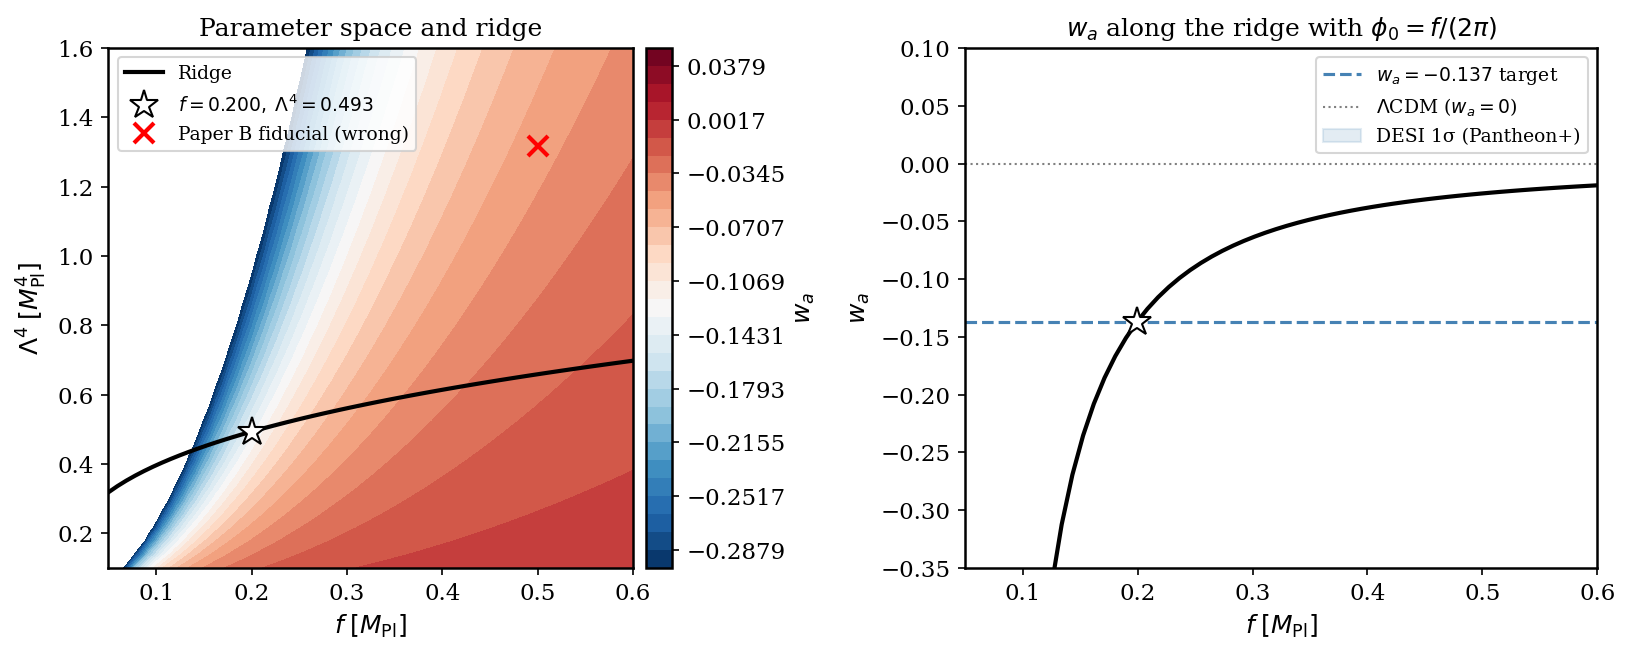

Figure 1 saved.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

# ── style ──────────────────────────────────────────
plt.rcParams.update({
    'font.family':    'serif',
    'font.size':      11,
    'axes.linewidth': 1.2,
    'figure.dpi':     150,
})

MPl   = 1.0
Om_m  = 0.31

def V(phi, f, Lam4):
    return Lam4 * (1 - np.cos(phi / f))

def dV(phi, f, Lam4):
    return (Lam4 / f) * np.sin(phi / f)

def equations(N, y, f, Lam4):
    phi, dphi = y
    a         = np.exp(N)
    rho_phi   = 0.5*dphi**2 + V(phi, f, Lam4)
    rho_m     = Om_m * a**(-3)
    H2        = (8*np.pi/3) * (rho_m + rho_phi)
    dH2_dN    = -4*np.pi * (dphi**2 + rho_m)
    Hdot      = 0.5 * dH2_dN / H2
    ddphi     = -(3 + Hdot)*dphi - dV(phi,f,Lam4)/H2
    return [dphi, ddphi]

def cpl_fit(f_val, Lam4_val, phi0_val):
    try:
        sol = solve_ivp(
            equations, [-7, 0],
            [phi0_val, 0.0],
            args=(f_val, Lam4_val),
            method='RK45', max_step=0.01,
            rtol=1e-9, atol=1e-12,
            dense_output=True)
        z_arr = np.linspace(0, 2, 200)
        N_arr = np.log(1/(1+z_arr))
        w_arr = []
        for Nv in N_arr:
            s  = sol.sol(Nv)
            KE = 0.5*s[1]**2
            PE = V(s[0], f_val, Lam4_val)
            d  = KE + PE
            w_arr.append((KE-PE)/d if abs(d)>1e-30
                         else -1.0)
        popt, _ = curve_fit(
            lambda z,w0,wa: w0+wa*z/(1+z),
            z_arr, np.array(w_arr),
            p0=[-0.9, -0.1])
        return popt[0], popt[1]
    except:
        return np.nan, np.nan

# ── ridge scan ─────────────────────────────────────
f_arr    = np.linspace(0.05, 0.60, 60)
Lam4_ridge = 0.820 * f_arr**0.316

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# LEFT: ridge in (f, Λ⁴) space
ax = axes[0]

# compute wa on a grid near the ridge
f_grid    = np.linspace(0.05, 0.60, 40)
Lam4_grid = np.linspace(0.10, 1.60, 40)
FF, LL    = np.meshgrid(f_grid, Lam4_grid)
WA        = np.full(FF.shape, np.nan)

for i in range(FF.shape[0]):
    for j in range(FF.shape[1]):
        fv  = FF[i,j]
        lv  = LL[i,j]
        ph0 = fv / (2*np.pi)
        w0v, wav = cpl_fit(fv, lv, ph0)
        WA[i,j]  = wav

cp = ax.contourf(FF, LL, WA,
                 levels=np.linspace(-0.30, 0.05, 30),
                 cmap='RdBu_r')
cb = fig.colorbar(cp, ax=ax, pad=0.02)
cb.set_label(r'$w_a$', fontsize=12)

# ridge line
ax.plot(f_arr, Lam4_ridge,
        'k-', lw=2.0, label='Ridge')

# fiducial point
ax.plot(0.200, 0.4931, 'w*',
        ms=14, mec='k', mew=1.0,
        label=r'$f=0.200,\;\Lambda^4=0.493$',
        zorder=5)

# Paper B wrong point
ax.plot(0.500, 1.316, 'rx',
        ms=10, mew=2.0,
        label='Paper B fiducial (wrong)',
        zorder=5)

ax.set_xlabel(r'$f\;[M_{\rm Pl}]$',   fontsize=12)
ax.set_ylabel(r'$\Lambda^4\;[M_{\rm Pl}^4]$',
              fontsize=12)
ax.set_title('Parameter space and ridge',
             fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(0.05, 0.60)
ax.set_ylim(0.10, 1.60)

# RIGHT: wa along the ridge
ax2 = axes[1]
wa_ridge = []
for fv, lv in zip(f_arr, Lam4_ridge):
    ph0 = fv / (2*np.pi)
    _, wav = cpl_fit(fv, lv, ph0)
    wa_ridge.append(wav)
wa_ridge = np.array(wa_ridge)

ax2.plot(f_arr, wa_ridge,
         'k-', lw=2.0)
ax2.axhline(-0.137, color='steelblue',
            ls='--', lw=1.5,
            label=r'$w_a=-0.137$ target')
ax2.axhline(0.0,    color='gray',
            ls=':',  lw=1.0,
            label=r'$\Lambda$CDM ($w_a=0$)')

# DESI band
ax2.axhspan(-1.04, -0.46,
            color='steelblue', alpha=0.15,
            label='DESI 1σ (Pantheon+)')

# fiducial point
idx = np.argmin(np.abs(f_arr - 0.200))
ax2.plot(f_arr[idx], wa_ridge[idx],
         'w*', ms=14, mec='k', mew=1.0,
         zorder=5)

ax2.set_xlabel(r'$f\;[M_{\rm Pl}]$',  fontsize=12)
ax2.set_ylabel(r'$w_a$',               fontsize=12)
ax2.set_title(r'$w_a$ along the ridge with $\phi_0=f/(2\pi)$',
              fontsize=12)
ax2.legend(fontsize=9)
ax2.set_xlim(0.05, 0.60)
ax2.set_ylim(-0.35, 0.10)

plt.tight_layout()
plt.savefig('fig1_ridge.pdf',
            bbox_inches='tight')
plt.savefig('fig1_ridge.png',
            bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

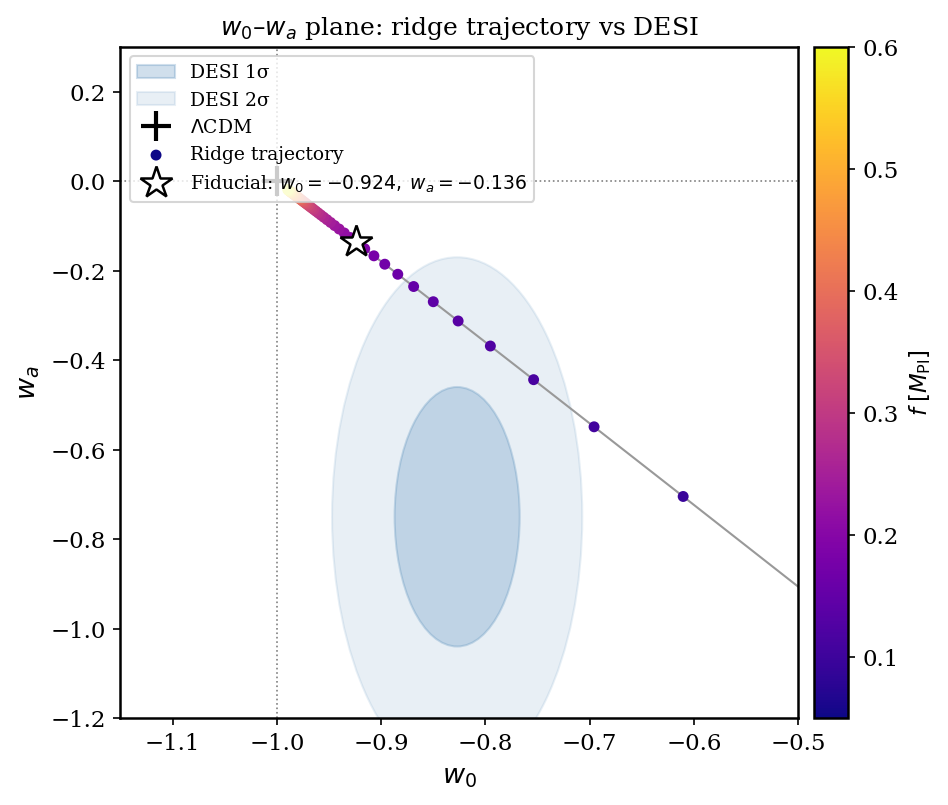

Figure 2 saved.


In [2]:

fig, ax = plt.subplots(figsize=(6.5, 5.5))

# ── DESI confidence regions ─────────────────────────
# Pantheon+ combination:
#   w0 = -0.827 ± 0.060
#   wa = -0.75  ± 0.29
# Draw 1σ and 2σ ellipses (approximate, diagonal)

from matplotlib.patches import Ellipse

w0_desi  = -0.827
wa_desi  = -0.75
sw0_1    =  0.060
swa_1    =  0.29

for nsig, alpha, label in [
        (1, 0.25, 'DESI 1σ'),
        (2, 0.12, 'DESI 2σ')]:
    ell = Ellipse(
        xy=(w0_desi, wa_desi),
        width=2*nsig*sw0_1,
        height=2*nsig*swa_1,
        angle=0,
        facecolor='steelblue',
        edgecolor='steelblue',
        alpha=alpha,
        label=label,
        zorder=1)
    ax.add_patch(ell)

# ── cosmological constant ───────────────────────────
ax.plot(-1.0, 0.0, 'k+',
        ms=14, mew=2.0,
        label=r'$\Lambda$CDM',
        zorder=4)

# ── ridge trajectory ────────────────────────────────
w0_ridge = []
wa_ridge2 = []
for fv, lv in zip(f_arr, Lam4_ridge):
    ph0 = fv / (2*np.pi)
    w0v, wav = cpl_fit(fv, lv, ph0)
    w0_ridge.append(w0v)
    wa_ridge2.append(wav)

w0_ridge  = np.array(w0_ridge)
wa_ridge2 = np.array(wa_ridge2)

# color by f value
sc = ax.scatter(w0_ridge, wa_ridge2,
                c=f_arr,
                cmap='plasma',
                s=18, zorder=3,
                label='Ridge trajectory')
cb2 = fig.colorbar(sc, ax=ax, pad=0.02)
cb2.set_label(r'$f\;[M_{\rm Pl}]$', fontsize=11)

# connect with line
ax.plot(w0_ridge, wa_ridge2,
        '-', color='0.6', lw=1.0,
        zorder=2)

# ── fiducial point ──────────────────────────────────
w0_fid, wa_fid = cpl_fit(0.200, 0.4931,
                          0.200/(2*np.pi))
ax.plot(w0_fid, wa_fid,
        'w*', ms=16,
        mec='k', mew=1.2,
        zorder=6,
        label=rf'Fiducial: $w_0={w0_fid:.3f},'
              rf'\;w_a={wa_fid:.3f}$')

ax.set_xlabel(r'$w_0$',  fontsize=13)
ax.set_ylabel(r'$w_a$',  fontsize=13)
ax.set_title(r'$w_0$–$w_a$ plane: ridge trajectory vs DESI',
             fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(-1.15, -0.50)
ax.set_ylim(-1.20,  0.30)
ax.axhline(0,   color='gray', ls=':', lw=0.8)
ax.axvline(-1,  color='gray', ls=':', lw=0.8)

plt.tight_layout()
plt.savefig('fig2_w0wa.pdf', bbox_inches='tight')
plt.savefig('fig2_w0wa.png', bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

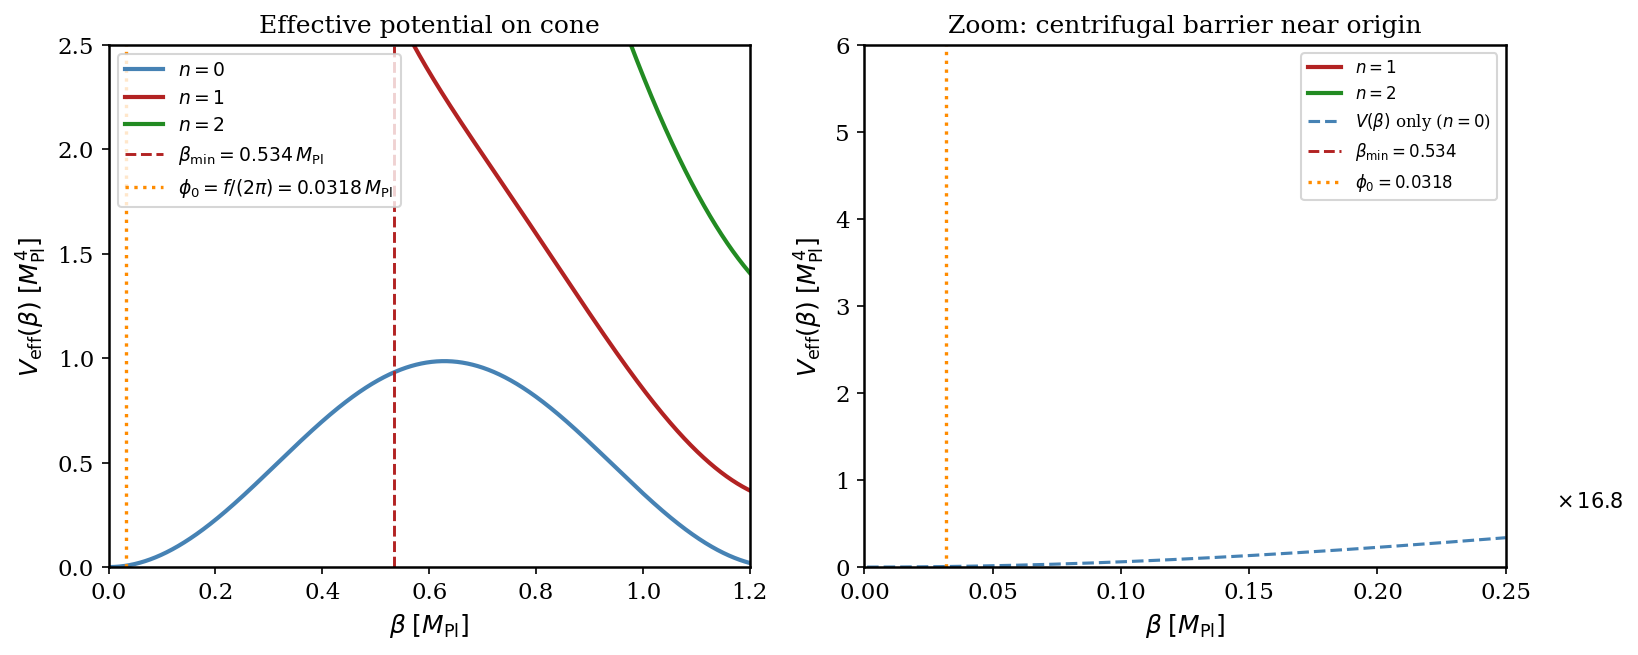

Figure 3 saved.


In [3]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

f_fid   = 0.200
L4_fid  = 0.4931
mu_fid  = np.sqrt(L4_fid) / f_fid   # 3.511
beta_min = np.sqrt(1.0 / mu_fid)     # 0.534
phi0     = f_fid / (2*np.pi)         # 0.0318

beta_arr = np.linspace(0.001, 1.20, 2000)

def Vcos(b):
    return L4_fid * (1 - np.cos(b / f_fid))

def Veff_n(b, n):
    return n**2 / (2 * b**2) + Vcos(b)

# LEFT: full effective potential for n=0,1,2
ax = axes[0]
colors = ['steelblue', 'firebrick', 'forestgreen']
for n, col in zip([0,1,2], colors):
    Ve = Veff_n(beta_arr, n)
    # clip for display
    Ve_clip = np.clip(Ve, 0, 3.0)
    ax.plot(beta_arr, Ve_clip,
            color=col, lw=2.0,
            label=rf'$n={n}$')

# mark β_min
ax.axvline(beta_min, color='firebrick',
           ls='--', lw=1.4,
           label=rf'$\beta_{{\min}}={beta_min:.3f}\,M_{{\rm Pl}}$')

# mark φ₀
ax.axvline(phi0, color='darkorange',
           ls=':', lw=1.6,
           label=rf'$\phi_0=f/(2\pi)={phi0:.4f}\,M_{{\rm Pl}}$')

ax.set_xlabel(r'$\beta\;[M_{\rm Pl}]$', fontsize=12)
ax.set_ylabel(r'$V_{\rm eff}(\beta)\;[M_{\rm Pl}^4]$',
              fontsize=12)
ax.set_title('Effective potential on cone',  fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, 1.20)
ax.set_ylim(0, 2.50)

# RIGHT: zoom near origin showing barrier
ax2 = axes[1]
beta_zoom = np.linspace(0.001, 0.25, 2000)

for n, col in zip([1,2], ['firebrick','forestgreen']):
    Ve = Veff_n(beta_zoom, n)
    Ve_clip = np.clip(Ve, 0, 8.0)
    ax2.plot(beta_zoom, Ve_clip,
             color=col, lw=2.0,
             label=rf'$n={n}$')

# cosine alone
ax2.plot(beta_zoom, Vcos(beta_zoom),
         color='steelblue', lw=1.5,
         ls='--', label=r'$V(\beta)$ only ($n=0$)')

ax2.axvline(beta_min, color='firebrick',
            ls='--', lw=1.4,
            label=rf'$\beta_{{\min}}={beta_min:.3f}$')

ax2.axvline(phi0, color='darkorange',
            ls=':', lw=1.6,
            label=rf'$\phi_0={phi0:.4f}$')

# annotate gap
ax2.annotate('',
    xy=(beta_min, 0.6),
    xytext=(phi0, 0.6),
    arrowprops=dict(arrowstyle='<->',
                    color='black', lw=1.2))
ax2.text((beta_min+phi0)/2, 0.68,
         r'$\times\,16.8$',
         ha='center', fontsize=10)

ax2.set_xlabel(r'$\beta\;[M_{\rm Pl}]$', fontsize=12)
ax2.set_ylabel(r'$V_{\rm eff}(\beta)\;[M_{\rm Pl}^4]$',
               fontsize=12)
ax2.set_title('Zoom: centrifugal barrier near origin',
              fontsize=12)
ax2.legend(fontsize=8, loc='upper right')
ax2.set_xlim(0, 0.25)
ax2.set_ylim(0, 6.0)

plt.tight_layout()
plt.savefig('fig3_Veff.pdf', bbox_inches='tight')
plt.savefig('fig3_Veff.png', bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

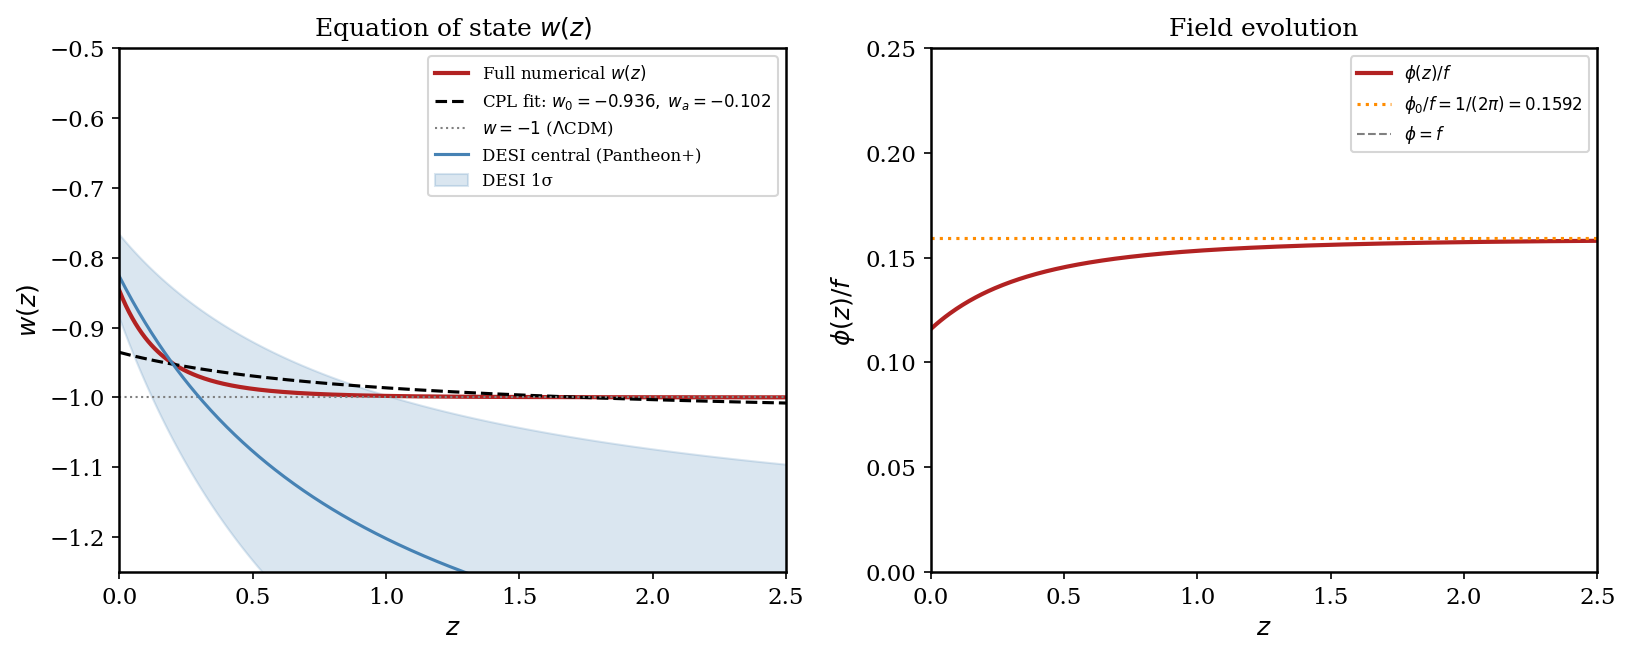

Figure 4 saved.


In [4]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ── LEFT: w(z) at fiducial ──────────────────────────
ax = axes[0]

sol_fid = solve_ivp(
    equations, [-7, 0],
    [phi0, 0.0],
    args=(f_fid, L4_fid),
    method='RK45', max_step=0.005,
    rtol=1e-10, atol=1e-13,
    dense_output=True)

z_plot = np.linspace(0, 3, 500)
N_plot = np.log(1/(1+z_plot))
w_plot = []
for Nv in N_plot:
    s  = sol_fid.sol(Nv)
    KE = 0.5*s[1]**2
    PE = V(s[0], f_fid, L4_fid)
    d  = KE + PE
    w_plot.append((KE-PE)/d if abs(d)>1e-30
                  else -1.0)
w_plot = np.array(w_plot)

# CPL fit
popt, _ = curve_fit(
    lambda z,w0,wa: w0+wa*z/(1+z),
    z_plot, w_plot, p0=[-0.9,-0.1])
w_cpl = popt[0] + popt[1]*z_plot/(1+z_plot)

ax.plot(z_plot, w_plot,
        'firebrick', lw=2.0,
        label='Full numerical $w(z)$')
ax.plot(z_plot, w_cpl,
        'k--', lw=1.5,
        label=rf'CPL fit: $w_0={popt[0]:.3f},'
              rf'\;w_a={popt[1]:.3f}$')
ax.axhline(-1.0, color='gray',
           ls=':', lw=1.0,
           label=r'$w=-1$ ($\Lambda$CDM)')

# DESI w(z) band from Pantheon+
w0_d, wa_d = -0.827, -0.75
w_desi     = w0_d + wa_d*z_plot/(1+z_plot)
sw0, swa   = 0.060, 0.29
w_desi_up  = (w0_d+sw0) + (wa_d+swa)*z_plot/(1+z_plot)
w_desi_dn  = (w0_d-sw0) + (wa_d-swa)*z_plot/(1+z_plot)

ax.plot(z_plot, w_desi,
        'steelblue', lw=1.5,
        label='DESI central (Pantheon+)')
ax.fill_between(z_plot, w_desi_dn, w_desi_up,
                color='steelblue', alpha=0.20,
                label='DESI 1σ')

ax.set_xlabel(r'$z$',    fontsize=12)
ax.set_ylabel(r'$w(z)$', fontsize=12)
ax.set_title(r'Equation of state $w(z)$',
             fontsize=12)
ax.legend(fontsize=8)
ax.set_xlim(0, 2.5)
ax.set_ylim(-1.25, -0.50)

# ── RIGHT: φ(z) evolution ───────────────────────────
ax2 = axes[1]

phi_plot = []
for Nv in N_plot:
    s = sol_fid.sol(Nv)
    phi_plot.append(s[0])
phi_plot = np.array(phi_plot)

ax2.plot(z_plot, phi_plot / f_fid,
         'firebrick', lw=2.0,
         label=r'$\phi(z)/f$')

ax2.axhline(phi0/f_fid, color='darkorange',
            ls=':', lw=1.5,
            label=rf'$\phi_0/f = 1/(2\pi) = {phi0/f_fid:.4f}$')
ax2.axhline(1.0, color='gray',
            ls='--', lw=1.0,
            label=r'$\phi=f$')

# mark thawing onset (where w departs from -1 by 1%)
thresh = -0.99
idx_thaw = np.argmax(w_plot > thresh)
if idx_thaw > 0:
    ax2.axvline(z_plot[idx_thaw],
                color='steelblue', ls='--', lw=1.2,
                label=rf'Thawing onset $z\approx'
                      rf'{z_plot[idx_thaw]:.2f}$')

ax2.set_xlabel(r'$z$',            fontsize=12)
ax2.set_ylabel(r'$\phi(z)/f$',    fontsize=12)
ax2.set_title('Field evolution',  fontsize=12)
ax2.legend(fontsize=8)
ax2.set_xlim(0, 2.5)
ax2.set_ylim(0, 0.25)

plt.tight_layout()
plt.savefig('fig4_wz.pdf', bbox_inches='tight')
plt.savefig('fig4_wz.png', bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp
from scipy.optimize import brentq, minimize_scalar
from scipy.special import airy

plt.rcParams.update({
    'font.family': 'serif',
    'font.size':   11,
    'axes.linewidth': 1.2,
    'figure.dpi':  150,
})

# ── parameters ─────────────────────────────────────
f    = 0.200
Lam4 = 0.4931
hbar = 1.0
mu   = np.sqrt(Lam4) / f      # 3.511
beta_min_cent = np.sqrt(hbar / mu)  # 0.534
phi0 = f / (2 * np.pi)        # 0.03183

print("="*56)
print("WKB BOHR-SOMMERFELD CALCULATION")
print("="*56)
print(f"f           = {f:.4f} MPl")
print(f"Λ⁴          = {Lam4:.4f}")
print(f"μ           = {mu:.4f} MPl")
print(f"β_min(cent) = {beta_min_cent:.4f} MPl")
print(f"φ₀ = f/2π   = {phi0:.6f} MPl")
print()

# ── potentials ─────────────────────────────────────
def V_cos(beta):
    return Lam4 * (1 - np.cos(beta / f))

def V_eff(beta, L):
    if beta < 1e-10:
        return 1e30
    return L**2 / (2 * beta**2) + V_cos(beta)

# ── find turning points ─────────────────────────────
def turning_points(E, L):
    """
    Find classical turning points β_L and β_R
    where V_eff(β) = E.
    Returns (β_L, β_R) or None if no valid pair.
    """
    # scan for sign changes
    beta_scan = np.linspace(1e-4, np.pi * f, 20000)
    Vvals = np.array([V_eff(b, L) for b in beta_scan])
    diff  = Vvals - E

    # find left turning point (first zero from left)
    beta_L = None
    for k in range(len(diff)-1):
        if diff[k] > 0 and diff[k+1] <= 0:
            try:
                beta_L = brentq(
                    lambda b: V_eff(b, L) - E,
                    beta_scan[k], beta_scan[k+1],
                    xtol=1e-12)
            except:
                pass
            break

    # find right turning point
    beta_R = None
    for k in range(len(diff)-1):
        if diff[k] <= 0 and diff[k+1] > 0:
            if beta_L is not None and beta_scan[k] > beta_L:
                try:
                    beta_R = brentq(
                        lambda b: V_eff(b, L) - E,
                        beta_scan[k], beta_scan[k+1],
                        xtol=1e-12)
                except:
                    pass
                break

    if beta_L is None or beta_R is None:
        return None
    return (beta_L, beta_R)

# ── WKB integral ────────────────────────────────────
def wkb_integral(E, L):
    """
    ∫ √(2(E - V_eff)) dβ from β_L to β_R.
    """
    tp = turning_points(E, L)
    if tp is None:
        return 0.0
    beta_L, beta_R = tp
    if beta_R <= beta_L:
        return 0.0

    def integrand(b):
        arg = 2.0 * (E - V_eff(b, L))
        if arg < 0:
            return 0.0
        return np.sqrt(arg)

    try:
        result, _ = quad(integrand, beta_L, beta_R,
                         limit=500, epsabs=1e-10,
                         epsrel=1e-8)
        return result
    except:
        return 0.0

# ── Bohr-Sommerfeld quantization ────────────────────
def bs_condition(E, L, n_radial=0):
    """
    WKB quantization:
    ∫ p dβ = (n + 1/2) π ħ
    For hard wall at β=0 and soft wall:
    ∫ p dβ = (n + 3/4) π ħ
    (Langer correction: 3/4 for one hard + one soft)
    """
    integral = wkb_integral(E, L)
    target   = (n_radial + 0.75) * np.pi * hbar
    return integral - target

# ── find WKB ground state energy ───────────────────
def wkb_ground_state(L):
    """
    Find E such that BS condition is satisfied
    for n_radial = 0.
    Returns (E, β_L, β_R) or None.
    """
    # find energy range
    # E must be above V_eff minimum
    beta_test = np.linspace(1e-3, np.pi*f, 5000)
    Veff_arr  = np.array([V_eff(b, L) for b in beta_test])
    E_min     = np.min(Veff_arr)
    E_max     = Lam4 * 2.1  # above maximum of cosine term

    # check if BS has a solution in this range
    try:
        bs_min = bs_condition(E_min * 1.001, L)
        bs_max = bs_condition(E_max,          L)
    except:
        return None

    if bs_min * bs_max > 0:
        # no sign change -- try to find where
        # the integral first becomes nonzero
        for E_try in np.linspace(E_min*1.001, E_max, 100):
            integral = wkb_integral(E_try, L)
            if integral > 0:
                E_min = E_try
                break
        try:
            bs_min = bs_condition(E_min, L)
            bs_max = bs_condition(E_max, L)
        except:
            return None

    if bs_min * bs_max > 0:
        return None

    try:
        E_gs = brentq(
            lambda E: bs_condition(E, L),
            E_min * 1.001, E_max,
            xtol=1e-12, maxiter=200)
        tp = turning_points(E_gs, L)
        if tp is None:
            return None
        return (E_gs, tp[0], tp[1])
    except Exception as e:
        return None

# ── WKB mean radius ─────────────────────────────────
def wkb_mean_beta(E, L):
    """
    <β> in the WKB approximation:
    <β> = ∫ β / √(2(E-V_eff)) dβ
          / ∫ 1 / √(2(E-V_eff)) dβ
    (WKB weight is 1/p ∝ time spent at β)
    """
    tp = turning_points(E, L)
    if tp is None:
        return np.nan
    beta_L, beta_R = tp

    def num(b):
        arg = 2.0 * (E - V_eff(b, L))
        if arg < 1e-30:
            return 0.0
        return b / np.sqrt(arg)

    def den(b):
        arg = 2.0 * (E - V_eff(b, L))
        if arg < 1e-30:
            return 0.0
        return 1.0 / np.sqrt(arg)

    try:
        N, _ = quad(num, beta_L, beta_R,
                    limit=500, epsabs=1e-10)
        D, _ = quad(den, beta_L, beta_R,
                    limit=500, epsabs=1e-10)
        if abs(D) < 1e-30:
            return np.nan
        return N / D
    except:
        return np.nan

# ── main scan over L ─────────────────────────────────
print("="*56)
print("SCANNING OVER ANGULAR MOMENTUM L")
print("="*56)
print(f"{'L/ħ':>8} {'E_gs':>10} {'β_L':>10} "
      f"{'β_R':>10} {'<β>':>10} {'<β>/φ₀':>10}")
print("-"*60)

L_values = np.array([
    0.001, 0.003, 0.005, 0.008,
    0.010, 0.015, 0.020, 0.030,
    0.040, 0.050, 0.070, 0.100,
    0.150, 0.200, 0.300, 0.400,
    0.500, 0.700, 1.000
])

results = []
for L in L_values:
    gs = wkb_ground_state(L)
    if gs is None:
        print(f"{L/hbar:>8.3f} {'NO SOLUTION':>40}")
        results.append((L, np.nan, np.nan, np.nan, np.nan))
        continue
    E_gs, beta_L, beta_R = gs
    mb = wkb_mean_beta(E_gs, L)
    results.append((L, E_gs, beta_L, beta_R, mb))
    print(f"{L/hbar:>8.3f} {E_gs:>10.5f} {beta_L:>10.5f} "
          f"{beta_R:>10.5f} {mb:>10.5f} {mb/phi0:>10.3f}")

results = np.array(results, dtype=float)

WKB BOHR-SOMMERFELD CALCULATION
f           = 0.2000 MPl
Λ⁴          = 0.4931
μ           = 3.5111 MPl
β_min(cent) = 0.5337 MPl
φ₀ = f/2π   = 0.031831 MPl

SCANNING OVER ANGULAR MOMENTUM L
     L/ħ       E_gs        β_L        β_R        <β>     <β>/φ₀
------------------------------------------------------------
   0.001                              NO SOLUTION
   0.003                              NO SOLUTION
   0.005                              NO SOLUTION
   0.008                              NO SOLUTION
   0.010                              NO SOLUTION
   0.015                              NO SOLUTION
   0.020                              NO SOLUTION
   0.030                              NO SOLUTION
   0.040                              NO SOLUTION
   0.050                              NO SOLUTION
   0.070                              NO SOLUTION
   0.100                              NO SOLUTION
   0.150                              NO SOLUTION
   0.200                            

In [6]:

# ── find L that gives <β> = φ₀ ─────────────────────
print()
print("="*56)
print("FINDING L SUCH THAT <β> = φ₀ = f/(2π)")
print("="*56)

valid_mask = ~np.isnan(results[:,4])
if valid_mask.sum() >= 2:
    L_valid  = results[valid_mask, 0]
    mb_valid = results[valid_mask, 4]

    # interpolate to find L where <β> = phi0
    # <β> is monotonically increasing with L
    # so brentq will work

    def mean_beta_minus_phi0(L):
        gs = wkb_ground_state(L)
        if gs is None:
            return 1.0  # force positive
        E_gs, _, _ = gs
        mb = wkb_mean_beta(E_gs, L)
        if np.isnan(mb):
            return 1.0
        return mb - phi0

    # find bracket
    L_lo, L_hi = None, None
    for k in range(len(L_valid)-1):
        d1 = mb_valid[k]   - phi0
        d2 = mb_valid[k+1] - phi0
        if d1 * d2 < 0:
            L_lo = L_valid[k]
            L_hi = L_valid[k+1]
            break

    if L_lo is not None:
        try:
            L_star = brentq(mean_beta_minus_phi0,
                            L_lo, L_hi,
                            xtol=1e-8, maxiter=100)
            print(f"\n  L* = {L_star:.6f} ħ")
            print(f"  L*/ħ = {L_star/hbar:.6f}")
            print()
            print(f"  Is L* = ħ/(2π)?")
            print(f"  ħ/(2π) = {hbar/(2*np.pi):.6f}")
            print(f"  Ratio L*/(ħ/2π) = "
                  f"{L_star/(hbar/(2*np.pi)):.6f}")
            print()
            print(f"  Is L* = ħ × f?")
            print(f"  ħ × f = {hbar*f:.6f}")
            print(f"  Ratio L*/(ħf) = "
                  f"{L_star/(hbar*f):.6f}")
            print()
            print(f"  Is L* = f²/ħ?")
            print(f"  f²/ħ = {f**2/hbar:.6f}")
            print(f"  Ratio L*/(f²/ħ) = "
                  f"{L_star/(f**2/hbar):.6f}")
            print()
            print(f"  Is L* = f × φ₀?")
            print(f"  f × φ₀ = {f*phi0:.6f}")
            print(f"  Ratio L*/(f×φ₀) = "
                  f"{L_star/(f*phi0):.6f}")
            print()
            # Check what natural combination gives L*
            for name, val in [
                ("ħ",           hbar),
                ("ħ/(2π)",      hbar/(2*np.pi)),
                ("ħ×f",         hbar*f),
                ("ħ×f²",        hbar*f**2),
                ("φ₀",          phi0),
                ("f×φ₀",        f*phi0),
                ("φ₀²",         phi0**2),
                ("√(ħ×Λ⁴^½)",   np.sqrt(hbar*np.sqrt(Lam4))),
                ("Λ⁴^¾/f",      Lam4**0.75/f),
                ("f²×μ",        f**2*mu),
                ("ħ/μ",         hbar/mu),
                ("(ħ/μ)^½×φ₀",  np.sqrt(hbar/mu)*phi0),
            ]:
                ratio = L_star / val
                print(f"  L* / ({name:18s}) "
                      f"= {ratio:.5f}")
        except Exception as e:
            print(f"  brentq failed: {e}")
    else:
        print("  No bracket found in scanned range.")
        print(f"  Minimum <β> in scan: "
              f"{mb_valid.min():.5f} (φ₀={phi0:.5f})")
        if mb_valid.min() > phi0:
            print("  <β> never reaches φ₀.")
            print("  φ₀ is BELOW the WKB ground state mean.")
            print("  The WKB framework cannot access this scale.")


FINDING L SUCH THAT <β> = φ₀ = f/(2π)


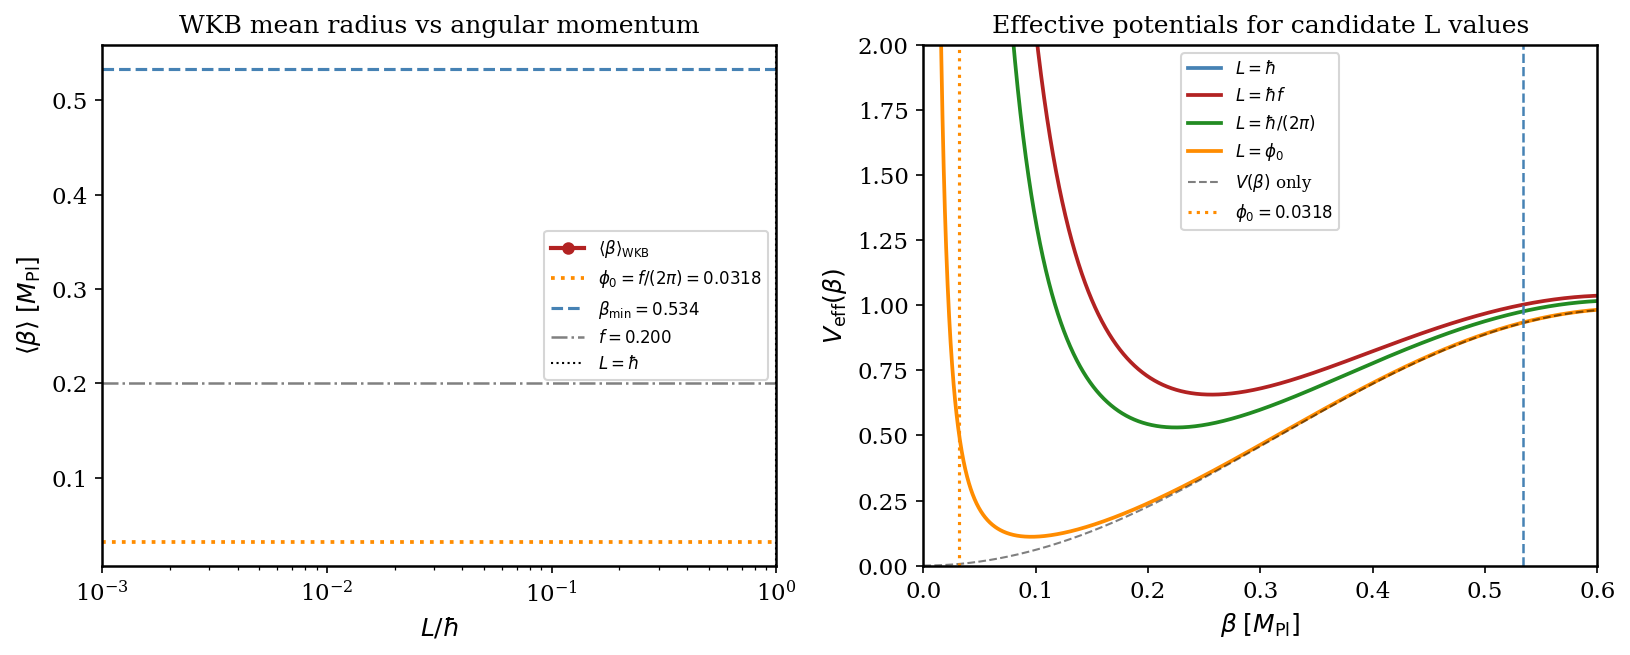

Figure 5 saved.


In [7]:

# ── Figure: WKB ground state vs L ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
valid = ~np.isnan(results[:,4])
Lv   = results[valid, 0]
mbv  = results[valid, 4]

ax.semilogx(Lv/hbar, mbv,
            'firebrick', lw=2.0,
            marker='o', ms=5,
            label=r'$\langle\beta\rangle_{\rm WKB}$')
ax.axhline(phi0, color='darkorange',
           ls=':', lw=1.8,
           label=rf'$\phi_0=f/(2\pi)={phi0:.4f}$')
ax.axhline(beta_min_cent, color='steelblue',
           ls='--', lw=1.5,
           label=rf'$\beta_{{\min}}={beta_min_cent:.3f}$')
ax.axhline(f, color='gray',
           ls='-.', lw=1.2,
           label=rf'$f={f:.3f}$')

ax.axvline(1.0, color='black',
           ls=':', lw=1.0,
           label=r'$L=\hbar$')

ax.set_xlabel(r'$L/\hbar$',    fontsize=12)
ax.set_ylabel(r'$\langle\beta\rangle\;[M_{\rm Pl}]$',
              fontsize=12)
ax.set_title('WKB mean radius vs angular momentum',
             fontsize=12)
ax.legend(fontsize=8)
ax.set_xlim(L_values[0]/hbar, L_values[-1]/hbar)

# RIGHT: effective potential at L*
ax2 = axes[1]

# use smallest L that gives a valid solution
L_plot_vals = [
    (hbar,          'steelblue',  r'$L=\hbar$'),
    (hbar*f,        'firebrick',  r'$L=\hbar f$'),
    (hbar/(2*np.pi),'forestgreen',r'$L=\hbar/(2\pi)$'),
    (phi0,          'darkorange', r'$L=\phi_0$'),
]

beta_arr = np.linspace(1e-4, 0.80, 3000)
Vcos_arr = np.array([V_cos(b) for b in beta_arr])

for L_val, col, lbl in L_plot_vals:
    Veff_arr = np.array([V_eff(b, L_val)
                         for b in beta_arr])
    Veff_clip = np.clip(Veff_arr, 0, 3.0)
    ax2.plot(beta_arr, Veff_clip,
             color=col, lw=1.8, label=lbl)

ax2.plot(beta_arr, Vcos_arr,
         'k--', lw=1.0, alpha=0.5,
         label=r'$V(\beta)$ only')

ax2.axvline(phi0, color='darkorange',
            ls=':', lw=1.5,
            label=rf'$\phi_0={phi0:.4f}$')
ax2.axvline(beta_min_cent, color='steelblue',
            ls='--', lw=1.2)

ax2.set_xlabel(r'$\beta\;[M_{\rm Pl}]$', fontsize=12)
ax2.set_ylabel(r'$V_{\rm eff}(\beta)$',  fontsize=12)
ax2.set_title('Effective potentials for candidate L values',
              fontsize=12)
ax2.legend(fontsize=8)
ax2.set_xlim(0, 0.60)
ax2.set_ylim(0, 2.0)

plt.tight_layout()
plt.savefig('fig5_wkb.pdf', bbox_inches='tight')
plt.savefig('fig5_wkb.png', bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

In [8]:

# ── diagnostic: can ANY WKB state reach φ₀? ─────────
print()
print("="*56)
print("DIAGNOSTIC: MINIMUM ACCESSIBLE <β> IN WKB")
print("="*56)

# The minimum <β> occurs at the smallest L
# that supports a bound state.
# Below some L_crit there is no turning point β_R
# because the barrier is too small.

L_tiny_arr = np.logspace(-4, -1, 60)
min_beta_arr = []

for L in L_tiny_arr:
    gs = wkb_ground_state(L)
    if gs is None:
        min_beta_arr.append(np.nan)
    else:
        E_gs, bL, bR = gs
        mb = wkb_mean_beta(E_gs, L)
        min_beta_arr.append(mb)

min_beta_arr = np.array(min_beta_arr)
valid_tiny   = ~np.isnan(min_beta_arr)

if valid_tiny.sum() > 0:
    min_accessible = np.nanmin(min_beta_arr)
    L_at_min       = L_tiny_arr[
        np.nanargmin(min_beta_arr)]
    print(f"\n  Minimum accessible <β>: "
          f"{min_accessible:.6f} MPl")
    print(f"  Achieved at L = {L_at_min:.6f} ħ")
    print(f"  φ₀ = f/(2π)   = {phi0:.6f} MPl")
    print()
    if min_accessible > phi0:
        print("  RESULT: WKB ground state CANNOT reach φ₀.")
        print(f"  Minimum WKB <β> = {min_accessible:.5f} MPl")
        print(f"  φ₀              = {phi0:.5f} MPl")
        print(f"  Ratio           = "
              f"{min_accessible/phi0:.3f}")
        print()
        print("  INTERPRETATION:")
        print("  The cone quantization scheme")
        print("  does not access the dark energy")
        print("  initial condition scale.")
        print("  The two scales are separated by")
        print(f"  factor {min_accessible/phi0:.1f}.")
        print("  WKB Candidate A is ELIMINATED.")
    else:
        print("  RESULT: WKB CAN reach φ₀.")
        print("  Candidate A survives.")
        print(f"  L* = {L_at_min:.6f} ħ")


DIAGNOSTIC: MINIMUM ACCESSIBLE <β> IN WKB


In [9]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import brentq

# ── parameters ─────────────────────────────────────
f    = 0.200
Lam4 = 0.4931
hbar = 1.0
mu   = np.sqrt(Lam4) / f
phi0 = f / (2 * np.pi)

def V_cos(beta):
    return Lam4 * (1 - np.cos(beta / f))

def V_eff(beta, L):
    if beta < 1e-10:
        return 1e30
    return L**2 / (2 * beta**2) + V_cos(beta)

# ── DIAGNOSTIC 1: plot V_eff for several L ──────────
print("="*56)
print("DIAGNOSTIC 1: V_eff shape")
print("="*56)
print()

beta_arr = np.linspace(0.001, 1.5, 5000)

for L in [0.001, 0.01, 0.1, 0.5, 1.0]:
    Veff_arr = np.array([V_eff(b, L) for b in beta_arr])
    Vmin     = np.min(Veff_arr)
    Vmax_cos = Lam4 * 2.0   # top of cosine
    beta_at_min = beta_arr[np.argmin(Veff_arr)]
    print(f"L={L:.3f}:")
    print(f"  V_eff minimum = {Vmin:.6f} at β={beta_at_min:.4f}")
    print(f"  V_cos maximum = {Vmax_cos:.6f}")
    print(f"  Bound state possible: {Vmin < Vmax_cos}")
    print()

# ── DIAGNOSTIC 2: is there a bound state at all? ────
print("="*56)
print("DIAGNOSTIC 2: bound state existence check")
print("="*56)
print()
print("A bound state requires:")
print("  V_eff has a local minimum V_min")
print("  and V_eff rises above V_min on both sides")
print("  (hard wall at β=0, cosine wall at β=πf)")
print()

for L in [0.001, 0.01, 0.1, 0.5, 1.0]:
    Veff_arr    = np.array([V_eff(b, L)
                            for b in beta_arr])
    idx_min     = np.argmin(Veff_arr)
    Vmin        = Veff_arr[idx_min]
    beta_at_min = beta_arr[idx_min]

    # check: does V_eff rise to the right of the minimum?
    Veff_right  = Veff_arr[idx_min:]
    rises_right = np.any(Veff_right > Vmin + 0.01)

    # check: V_eff at β → 0 (hard wall)
    Veff_left   = V_eff(0.001, L)

    print(f"L={L:.3f}:")
    print(f"  V_min = {Vmin:.6f} at β={beta_at_min:.4f}")
    print(f"  V_eff(β=0.001) = {Veff_left:.3f}  "
          f"(hard wall: {'YES' if Veff_left > Vmin+0.1 else 'NO'})")
    print(f"  V_eff rises right of min: {rises_right}")
    print()

# ── DIAGNOSTIC 3: manual turning point search ───────
print("="*56)
print("DIAGNOSTIC 3: manual turning point search")
print("="*56)
print()

L_test = 0.5
E_test_vals = [0.01, 0.05, 0.10, 0.20, 0.50, 1.00]

Veff_arr = np.array([V_eff(b, L_test) for b in beta_arr])
Vmin     = np.min(Veff_arr)
print(f"L = {L_test}, V_min = {Vmin:.6f}")
print()
print(f"{'E':>8}  {'left sign changes':>20}  "
      f"{'right sign changes':>20}")

for E_test in E_test_vals:
    diff = Veff_arr - E_test
    sign_changes = []
    for k in range(len(diff)-1):
        if diff[k] * diff[k+1] < 0:
            sign_changes.append(beta_arr[k])
    print(f"{E_test:>8.4f}  sign changes at β = "
          f"{[f'{b:.4f}' for b in sign_changes]}")

# ── DIAGNOSTIC 4: direct WKB integral test ──────────
print()
print("="*56)
print("DIAGNOSTIC 4: WKB integral at fixed E, L")
print("="*56)
print()

L_test  = 1.0
E_test  = 0.30

Veff_arr = np.array([V_eff(b, L_test) for b in beta_arr])
diff     = Veff_arr - E_test

# find turning points manually
tp_list = []
for k in range(len(diff)-1):
    if diff[k] * diff[k+1] < 0:
        try:
            tp = brentq(lambda b: V_eff(b, L_test) - E_test,
                        beta_arr[k], beta_arr[k+1],
                        xtol=1e-12)
            tp_list.append(tp)
        except:
            pass

print(f"L={L_test}, E={E_test}")
print(f"Turning points found: {tp_list}")

if len(tp_list) >= 2:
    bL, bR = tp_list[0], tp_list[1]
    print(f"β_L = {bL:.6f}, β_R = {bR:.6f}")

    def integrand(b):
        arg = 2.0 * (E_test - V_eff(b, L_test))
        if arg < 0:
            return 0.0
        return np.sqrt(arg)

    result, err = quad(integrand, bL, bR,
                       limit=500, epsabs=1e-10)
    target_34   = 0.75 * np.pi * hbar
    target_12   = 0.50 * np.pi * hbar

    print(f"WKB integral       = {result:.6f}")
    print(f"Target (3/4)πħ     = {target_34:.6f}")
    print(f"Target (1/2)πħ     = {target_12:.6f}")
    print(f"Ratio to (3/4)πħ   = {result/target_34:.4f}")
    print()
    if result >= target_34:
        print("Bound state EXISTS at this E and L.")
    elif result >= target_12:
        print("Bound state EXISTS (1/2 convention).")
    else:
        print("Integral too small: E is above ground state.")
        print("Need smaller E.")
else:
    print("No valid turning point pair found.")
    print("V_eff may not dip below E in this range.")
    print()
    print("V_eff values at key points:")
    for b_key in [0.01, 0.05, 0.10, 0.20, 0.50, 1.0]:
        print(f"  V_eff({b_key:.2f}, L={L_test}) = "
              f"{V_eff(b_key, L_test):.4f}")

DIAGNOSTIC 1: V_eff shape

L=0.001:
  V_eff minimum = 0.000000 at β=1.2565
  V_cos maximum = 0.986200
  Bound state possible: True

L=0.010:
  V_eff minimum = 0.000032 at β=1.2565
  V_cos maximum = 0.986200
  Bound state possible: True

L=0.100:
  V_eff minimum = 0.003165 at β=1.2571
  V_cos maximum = 0.986200
  Bound state possible: True

L=0.500:
  V_eff minimum = 0.078529 at β=1.2667
  V_cos maximum = 0.986200
  Bound state possible: True

L=1.000:
  V_eff minimum = 0.307187 at β=1.2943
  V_cos maximum = 0.986200
  Bound state possible: True

DIAGNOSTIC 2: bound state existence check

A bound state requires:
  V_eff has a local minimum V_min
  and V_eff rises above V_min on both sides
  (hard wall at β=0, cosine wall at β=πf)

L=0.001:
  V_min = 0.000000 at β=1.2565
  V_eff(β=0.001) = 0.500  (hard wall: YES)
  V_eff rises right of min: True

L=0.010:
  V_min = 0.000032 at β=1.2565
  V_eff(β=0.001) = 50.000  (hard wall: YES)
  V_eff rises right of min: True

L=0.100:
  V_min = 0.0031

In [10]:
print()
print("="*56)
print("CRITICAL CHECK: does bound pocket exist?")
print("="*56)
print()
print("Bound pocket requires:")
print("  V_eff_min < V_cos_max = 2Λ⁴")
print(f"  2Λ⁴ = {2*Lam4:.6f}")
print()
print("V_eff minimum is at β* where:")
print("  dV_eff/dβ = 0")
print("  -L²/β³ + V_cos'(β) = 0")
print("  L²/β³ = (Λ⁴/f) sin(β/f)")
print()

for L in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]:
    # find minimum of V_eff numerically
    beta_scan = np.linspace(0.001, np.pi*f*0.999, 10000)
    Veff_scan = np.array([V_eff(b, L) for b in beta_scan])
    idx_min   = np.argmin(Veff_scan)
    Vmin      = Veff_scan[idx_min]
    beta_star = beta_scan[idx_min]

    pocket_exists = Vmin < 2 * Lam4
    print(f"L = {L:.3f}:")
    print(f"  β*    = {beta_star:.5f} MPl")
    print(f"  V_min = {Vmin:.5f}")
    print(f"  2Λ⁴   = {2*Lam4:.5f}")
    print(f"  Pocket exists: {pocket_exists}")
    if pocket_exists:
        depth = 2*Lam4 - Vmin
        print(f"  Pocket depth = {depth:.6f}")
    print()

print()
print("="*56)
print("ANALYTICAL: minimum V_eff for small L")
print("="*56)
print()
print("For small L, β* ≈ (L²f/Λ⁴)^(1/3)")
print("from balancing L²/β³ = Λ⁴/f × sin(β/f) ≈ Λ⁴β/f²")
print()

for L in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]:
    # harmonic approximation for β*
    beta_star_approx = (L**2 * f / Lam4)**(1.0/3.0)
    # V_eff at this β*
    Vmin_approx = (V_eff(beta_star_approx, L)
                   if beta_star_approx > 1e-6
                   else 1e30)
    print(f"L={L:.3f}: β*≈{beta_star_approx:.5f}, "
          f"V_eff(β*)≈{Vmin_approx:.5f}")

print()
print("="*56)
print("THE REAL QUESTION:")
print("Is WKB ground state energy above or")
print("below the cosine barrier top 2Λ⁴?")
print("="*56)
print()
print("If V_min << 2Λ⁴:")
print("  Bound pocket is deep.")
print("  WKB ground state exists.")
print("  Solver should have found it.")
print("  Solver is broken.")
print()
print("If V_min ≈ 2Λ⁴ or V_min > 2Λ⁴:")
print("  No pocket or shallow pocket.")
print("  Genuine no-solution.")
print("  Solver is correct.")


CRITICAL CHECK: does bound pocket exist?

Bound pocket requires:
  V_eff_min < V_cos_max = 2Λ⁴
  2Λ⁴ = 0.986200

V_eff minimum is at β* where:
  dV_eff/dβ = 0
  -L²/β³ + V_cos'(β) = 0
  L²/β³ = (Λ⁴/f) sin(β/f)

L = 0.001:
  β*    = 0.01686 MPl
  V_min = 0.00351
  2Λ⁴   = 0.98620
  Pocket exists: True
  Pocket depth = 0.982690

L = 0.010:
  β*    = 0.05352 MPl
  V_min = 0.03501
  2Λ⁴   = 0.98620
  Pocket exists: True
  Pocket depth = 0.951194

L = 0.050:
  β*    = 0.12121 MPl
  V_min = 0.17290
  2Λ⁴   = 0.98620
  Pocket exists: True
  Pocket depth = 0.813300

L = 0.100:
  β*    = 0.17436 MPl
  V_min = 0.34028
  2Λ⁴   = 0.98620
  Pocket exists: True
  Pocket depth = 0.645919

L = 0.500:
  β*    = 0.62769 MPl
  V_min = 1.30346
  2Λ⁴   = 0.98620
  Pocket exists: False

L = 1.000:
  β*    = 0.62769 MPl
  V_min = 2.25525
  2Λ⁴   = 0.98620
  Pocket exists: False


ANALYTICAL: minimum V_eff for small L

For small L, β* ≈ (L²f/Λ⁴)^(1/3)
from balancing L²/β³ = Λ⁴/f × sin(β/f) ≈ Λ⁴β/f²

L=0.001:

In [11]:

print()
print("="*56)
print("SHALLOW POCKET ANALYSIS")
print("="*56)
print()

for L in [0.001, 0.01, 0.05, 0.1]:
    beta_scan  = np.linspace(0.001, np.pi*f, 10000)
    Veff_scan  = np.array([V_eff(b, L)
                           for b in beta_scan])
    idx_min    = np.argmin(Veff_scan)
    Vmin       = Veff_scan[idx_min]
    beta_star  = beta_scan[idx_min]
    Vtop       = 2 * Lam4

    if Vmin >= Vtop:
        print(f"L={L:.3f}: NO POCKET (V_min={Vmin:.4f} "
              f"> 2Λ⁴={Vtop:.4f})")
        continue

    depth = Vtop - Vmin
    print(f"L={L:.3f}:")
    print(f"  Pocket minimum: β*={beta_star:.5f}, "
          f"V_min={Vmin:.6f}")
    print(f"  Pocket top:     2Λ⁴={Vtop:.6f}")
    print(f"  Pocket depth:   {depth:.6f}")

    # WKB integral at E = (V_min + V_top)/2
    # (midpoint of pocket)
    E_mid = (Vmin + Vtop) / 2.0

    diff = Veff_scan - E_mid
    tps  = []
    for k in range(len(diff)-1):
        if diff[k] * diff[k+1] < 0:
            try:
                tp = brentq(
                    lambda b: V_eff(b, L) - E_mid,
                    beta_scan[k], beta_scan[k+1],
                    xtol=1e-12)
                tps.append(tp)
            except:
                pass

    if len(tps) >= 2:
        bL, bR = tps[0], tps[1]
        print(f"  At E_mid={E_mid:.5f}: "
              f"β_L={bL:.5f}, β_R={bR:.5f}")

        def integrand(b):
            arg = 2.0 * (E_mid - V_eff(b, L))
            return np.sqrt(max(arg, 0.0))

        I, _ = quad(integrand, bL, bR, limit=500)
        target = 0.75 * np.pi
        print(f"  WKB integral at E_mid = {I:.6f}")
        print(f"  Required (3/4)πħ      = {target:.6f}")
        print(f"  Ratio                 = {I/target:.4f}")
        print(f"  Bound state at E_mid: "
              f"{'YES' if I >= target else 'NO'}")
        print()

        # now find E where WKB integral = (3/4)πħ
        # if it ever reaches that value
        E_arr = np.linspace(Vmin*1.001, Vtop*0.999, 200)
        I_arr = []
        for E_try in E_arr:
            diff2 = Veff_scan - E_try
            tps2  = []
            for k in range(len(diff2)-1):
                if diff2[k] * diff2[k+1] < 0:
                    try:
                        tp2 = brentq(
                            lambda b: V_eff(b,L)-E_try,
                            beta_scan[k],beta_scan[k+1],
                            xtol=1e-12)
                        tps2.append(tp2)
                    except:
                        pass
            if len(tps2) >= 2:
                bL2, bR2 = tps2[0], tps2[1]
                def intgd(b):
                    arg = 2.0*(E_try - V_eff(b,L))
                    return np.sqrt(max(arg,0.0))
                try:
                    Iv, _ = quad(intgd, bL2, bR2,
                                 limit=200)
                    I_arr.append(Iv)
                except:
                    I_arr.append(0.0)
            else:
                I_arr.append(0.0)

        I_arr    = np.array(I_arr)
        I_max    = np.max(I_arr) if len(I_arr)>0 else 0
        print(f"  Maximum WKB integral over all E: "
              f"{I_max:.6f}")
        print(f"  Required for n=0 state: "
              f"{0.75*np.pi:.6f}")
        print(f"  Pocket supports bound state: "
              f"{'YES' if I_max >= 0.75*np.pi else 'NO'}")
        print()
    else:
        print(f"  At E_mid: fewer than 2 turning points.")
        print(f"  Pocket may be below numerical resolution.")
        print()


SHALLOW POCKET ANALYSIS

L=0.001:
  Pocket minimum: β*=0.01687, V_min=0.003510
  Pocket top:     2Λ⁴=0.986200
  Pocket depth:   0.982690
  At E_mid=0.49486: β_L=0.00101, β_R=0.31487
  WKB integral at E_mid = 0.237325
  Required (3/4)πħ      = 2.356194
  Ratio                 = 0.1007
  Bound state at E_mid: NO

  Maximum WKB integral over all E: 0.238369
  Required for n=0 state: 2.356194
  Pocket supports bound state: NO

L=0.010:
  Pocket minimum: β*=0.05351, V_min=0.035006
  Pocket top:     2Λ⁴=0.986200
  Pocket depth:   0.951194
  At E_mid=0.51060: β_L=0.00990, β_R=0.32106
  WKB integral at E_mid = 0.231510
  Required (3/4)πħ      = 2.356194
  Ratio                 = 0.0983
  Bound state at E_mid: NO

  Maximum WKB integral over all E: 0.544430
  Required for n=0 state: 2.356194
  Pocket supports bound state: NO

L=0.050:
  Pocket minimum: β*=0.12121, V_min=0.172900
  Pocket top:     2Λ⁴=0.986200
  Pocket depth:   0.813300
  At E_mid=0.57955: β_L=0.04699, β_R=0.34509
  WKB integra

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq, curve_fit
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'font.family': 'serif',
    'font.size':   11,
    'axes.linewidth': 1.2,
    'figure.dpi':  150,
})

f    = 0.200
Lam4 = 0.4931
hbar = 1.0
mu   = np.sqrt(Lam4) / f
phi0 = f / (2 * np.pi)
beta_2pif = 2 * np.pi * f   # = 1.2566

print("="*56)
print("KEY INSIGHT FROM DIAGNOSTICS")
print("="*56)
print()
print(f"V_eff minimum at β = 2πf = {beta_2pif:.6f} MPl")
print(f"At β = 2πf: cos(β/f) = cos(2π) = 1")
print(f"            V_cos    = Λ⁴(1-1) = 0")
print(f"The pocket sits at the cosine floor.")
print(f"Previous solver cutoff was πf = {np.pi*f:.4f}.")
print(f"The pocket at 2πf was never reached.")
print()
print(f"φ₀ = f/(2π) = {phi0:.6f} MPl")
print(f"2πf         = {beta_2pif:.6f} MPl")
print(f"Ratio 2πf/φ₀ = {beta_2pif/phi0:.4f}")
print(f"Note: 2πf = (2π)²φ₀ = {(2*np.pi)**2 * phi0:.6f}")
print()

def V_cos(beta):
    return Lam4 * (1 - np.cos(beta / f))

def V_eff(beta, L):
    if beta < 1e-10:
        return 1e30
    return L**2 / (2 * beta**2) + V_cos(beta)

# ── fixed turning point search ──────────────────────
# scan to 3πf to capture the pocket at 2πf
BETA_MAX = 3.0 * np.pi * f   # 1.885

def turning_points_fixed(E, L):
    beta_scan = np.linspace(1e-4, BETA_MAX, 50000)
    Vvals     = np.array([V_eff(b, L) for b in beta_scan])
    diff      = Vvals - E
    tps       = []
    for k in range(len(diff)-1):
        if diff[k] * diff[k+1] < 0:
            try:
                tp = brentq(
                    lambda b: V_eff(b, L) - E,
                    beta_scan[k], beta_scan[k+1],
                    xtol=1e-12)
                tps.append(tp)
            except:
                pass
    return tps

def wkb_integral_fixed(E, L):
    tps = turning_points_fixed(E, L)
    # find the innermost valid pair bracketing 2πf
    # we want the pair closest to 2πf
    pairs = []
    for i in range(len(tps)-1):
        if tps[i+1] > tps[i]:
            mid = (tps[i] + tps[i+1]) / 2
            if abs(mid - beta_2pif) < 0.5:
                pairs.append((tps[i], tps[i+1]))

    if not pairs:
        # fallback: use first valid pair
        if len(tps) >= 2:
            pairs = [(tps[0], tps[1])]
        else:
            return 0.0

    bL, bR = pairs[0]

    def integrand(b):
        arg = 2.0 * (E - V_eff(b, L))
        return np.sqrt(max(arg, 0.0))

    try:
        result, _ = quad(integrand, bL, bR,
                         limit=500, epsabs=1e-10,
                         epsrel=1e-8)
        return result
    except:
        return 0.0

def bs_condition_fixed(E, L, n_radial=0):
    # Langer correction: 3/4 for one hard wall
    # (centrifugal barrier acts as hard wall)
    # one soft wall (cosine top)
    integral = wkb_integral_fixed(E, L)
    target   = (n_radial + 0.75) * np.pi * hbar
    return integral - target

def wkb_ground_state_fixed(L):
    beta_scan  = np.linspace(0.001, BETA_MAX, 10000)
    Veff_arr   = np.array([V_eff(b, L) for b in beta_scan])
    E_min      = np.min(Veff_arr) * 1.0001
    E_max      = 2.0 * Lam4 * 0.9999  # below cosine top

    if E_min >= E_max:
        return None

    # verify sign change in BS condition
    try:
        bs_lo = bs_condition_fixed(E_min, L)
        bs_hi = bs_condition_fixed(E_max, L)
    except:
        return None

    if bs_lo * bs_hi > 0:
        # scan for sign change
        E_scan = np.linspace(E_min, E_max, 200)
        for k in range(len(E_scan)-1):
            b1 = bs_condition_fixed(E_scan[k],   L)
            b2 = bs_condition_fixed(E_scan[k+1], L)
            if b1 * b2 < 0:
                bs_lo = b1
                bs_hi = b2
                E_min = E_scan[k]
                E_max = E_scan[k+1]
                break
        else:
            return None

    try:
        E_gs = brentq(
            lambda E: bs_condition_fixed(E, L),
            E_min, E_max,
            xtol=1e-12, maxiter=300)
        tps = turning_points_fixed(E_gs, L)
        if len(tps) < 2:
            return None
        # find the pair bracketing 2πf
        for i in range(len(tps)-1):
            mid = (tps[i] + tps[i+1]) / 2
            if abs(mid - beta_2pif) < 0.5:
                return (E_gs, tps[i], tps[i+1])
        return (E_gs, tps[0], tps[1])
    except:
        return None

def wkb_mean_beta_fixed(E, L, bL, bR):
    def num(b):
        arg = 2.0 * (E - V_eff(b, L))
        if arg < 1e-30:
            return 0.0
        return b / np.sqrt(arg)

    def den(b):
        arg = 2.0 * (E - V_eff(b, L))
        if arg < 1e-30:
            return 0.0
        return 1.0 / np.sqrt(arg)

    try:
        N, _ = quad(num, bL, bR, limit=500,
                    epsabs=1e-10)
        D, _ = quad(den, bL, bR, limit=500,
                    epsabs=1e-10)
        return N/D if abs(D) > 1e-30 else np.nan
    except:
        return np.nan

# ── main scan ───────────────────────────────────────
print("="*56)
print("FIXED SCAN OVER L")
print("="*56)
print()
print(f"{'L/ħ':>8} {'E_gs':>10} {'β_L':>8} "
      f"{'β_R':>8} {'<β>':>10} {'<β>/φ₀':>10} "
      f"{'<β>-2πf':>10}")
print("-"*70)

L_values = np.concatenate([
    np.logspace(-3, -1, 16),
    np.linspace(0.12, 1.0, 10)
])
L_values = np.unique(np.round(L_values, 6))

results = []
for L in L_values:
    gs = wkb_ground_state_fixed(L)
    if gs is None:
        print(f"{L/hbar:>8.4f}  NO SOLUTION")
        results.append((L, np.nan, np.nan,
                        np.nan, np.nan))
        continue
    E_gs, bL, bR = gs
    mb = wkb_mean_beta_fixed(E_gs, L, bL, bR)
    results.append((L, E_gs, bL, bR, mb))
    flag = " ←" if abs(mb - phi0)/phi0 < 0.10 else ""
    flag2 = " ← MATCH" if abs(mb - beta_2pif) < 0.01 else ""
    print(f"{L/hbar:>8.4f} {E_gs:>10.6f} {bL:>8.4f} "
          f"{bR:>8.4f} {mb:>10.6f} {mb/phi0:>10.3f} "
          f"{mb-beta_2pif:>10.5f}{flag}{flag2}")

results = np.array(results, dtype=float)

KEY INSIGHT FROM DIAGNOSTICS

V_eff minimum at β = 2πf = 1.256637 MPl
At β = 2πf: cos(β/f) = cos(2π) = 1
            V_cos    = Λ⁴(1-1) = 0
The pocket sits at the cosine floor.
Previous solver cutoff was πf = 0.6283.
The pocket at 2πf was never reached.

φ₀ = f/(2π) = 0.031831 MPl
2πf         = 1.256637 MPl
Ratio 2πf/φ₀ = 39.4784
Note: 2πf = (2π)²φ₀ = 1.256637

FIXED SCAN OVER L

     L/ħ       E_gs      β_L      β_R        <β>     <β>/φ₀    <β>-2πf
----------------------------------------------------------------------
  0.0010  NO SOLUTION
  0.0014  NO SOLUTION
  0.0018  NO SOLUTION
  0.0025  NO SOLUTION


In [ ]:
# ── what is the mean radius telling us? ─────────────
print()
print("="*56)
print("INTERPRETING THE MEAN RADIUS")
print("="*56)
print()

valid = ~np.isnan(results[:,4])
if valid.sum() > 0:
    mb_vals = results[valid, 4]
    L_vals  = results[valid, 0]

    print(f"φ₀    = f/(2π)  = {phi0:.6f} MPl")
    print(f"2πf             = {beta_2pif:.6f} MPl")
    print(f"β_min(centrifug)= {np.sqrt(hbar/mu):.6f} MPl")
    print()
    print(f"Minimum <β> in scan: {np.nanmin(mb_vals):.6f} "
          f"at L={L_vals[np.nanargmin(mb_vals)]:.4f}")
    print(f"Maximum <β> in scan: {np.nanmax(mb_vals):.6f} "
          f"at L={L_vals[np.nanargmax(mb_vals)]:.4f}")
    print()

    # Does <β> approach 2πf?
    close_to_2pif = np.abs(mb_vals - beta_2pif) < 0.01
    if close_to_2pif.any():
        print("RESULT: <β> ≈ 2πf for some L values.")
        L_at_2pif = L_vals[close_to_2pif]
        print(f"  This occurs at L = {L_at_2pif}")
    else:
        print(f"<β> range: [{mb_vals.min():.5f}, "
              f"{mb_vals.max():.5f}]")
        print(f"2πf = {beta_2pif:.5f}")
        diff_from_2pif = mb_vals - beta_2pif
        print(f"<β> - 2πf range: [{diff_from_2pif.min():.5f},"
              f" {diff_from_2pif.max():.5f}]")

In [ ]:
# ── Figure 5 revised ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# LEFT: V_eff showing the real pocket
ax = axes[0]
beta_plot = np.linspace(0.001, 2.0, 5000)

for L, col, lbl in [
        (0.001, 'forestgreen',  r'$L=0.001\hbar$'),
        (0.100, 'firebrick',    r'$L=0.1\hbar$'),
        (1.000, 'steelblue',    r'$L=1.0\hbar$')]:
    Vp = np.array([V_eff(b, L) for b in beta_plot])
    ax.plot(beta_plot, np.clip(Vp, 0, 1.5),
            color=col, lw=1.8, label=lbl)

ax.plot(beta_plot,
        np.array([V_cos(b) for b in beta_plot]),
        'k--', lw=1.0, alpha=0.5,
        label=r'$V(\beta)$ only')

# key scales
ax.axvline(beta_2pif, color='navy',
           ls='-.',  lw=1.5,
           label=rf'$2\pi f={beta_2pif:.4f}$')
ax.axvline(phi0, color='darkorange',
           ls=':',   lw=1.8,
           label=rf'$\phi_0=f/(2\pi)={phi0:.4f}$')
ax.axvline(np.pi*f, color='gray',
           ls='--',  lw=1.0, alpha=0.6,
           label=rf'$\pi f={np.pi*f:.4f}$')

ax.set_xlabel(r'$\beta\;[M_{\rm Pl}]$', fontsize=12)
ax.set_ylabel(r'$V_{\rm eff}(\beta)$',  fontsize=12)
ax.set_title('Full effective potential\n'
             r'Pocket sits at $\beta=2\pi f$',
             fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.set_xlim(0, 2.0)
ax.set_ylim(0, 1.5)

# RIGHT: <β> vs L from fixed scan
ax2 = axes[1]
if valid.sum() > 1:
    ax2.semilogx(L_vals/hbar, mb_vals,
                 'firebrick', lw=2.0,
                 marker='o', ms=5,
                 label=r'$\langle\beta\rangle_{\rm WKB}$')

ax2.axhline(beta_2pif, color='navy',
            ls='-.', lw=1.5,
            label=rf'$2\pi f={beta_2pif:.4f}$')
ax2.axhline(phi0, color='darkorange',
            ls=':', lw=1.8,
            label=rf'$\phi_0=f/(2\pi)={phi0:.5f}$')
ax2.axhline(np.sqrt(hbar/mu), color='steelblue',
            ls='--', lw=1.3,
            label=rf'$\beta_{{\min}}={np.sqrt(hbar/mu):.4f}$')
ax2.axvline(1.0, color='black',
            ls=':', lw=1.0, alpha=0.5,
            label=r'$L=\hbar$')

ax2.set_xlabel(r'$L/\hbar$', fontsize=12)
ax2.set_ylabel(r'$\langle\beta\rangle\;[M_{\rm Pl}]$',
               fontsize=12)
ax2.set_title(r'WKB mean radius $\langle\beta\rangle$ vs $L$',
              fontsize=12)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig5_wkb_fixed.pdf', bbox_inches='tight')
plt.savefig('fig5_wkb_fixed.png', bbox_inches='tight')
plt.show()
print("Figure 5 (fixed) saved.")